# Final Project: Kalshi Market Making in short-dated SPX Events

Chris Mulligan (12502987), George Lord (12243747), Max Zhalilo (12341701)

# Content

0. Abstract
1. Introduction
2. Data
3. Techniques and Theory Details in the Strategy
4. Implementation of our Strategy
5. Result/Analysis

# 0. Abstract

We use statistical modeling & black-scholes to price Kalshi short-dates SPX events. We simulate an automated market making strategy in these events using a simulator that directly interfaces with our trading modules. We delta hedge SPX exposure by trading the SPY ETF. We test the performance of our strategy over 2 months.

# 1. Introduction

In modern financial markets, algorithmic trading and automated market making have become central components of liquidity provision and price discovery. Electronic Market Makers such as Jump & Virtu have begun to expand into prediction markets such as Kalshi & Polymarket to profit from their increasing trading volumes. In this project, we develop and test a fully systematic market-making strategy for short-dated S&P 500 (SPX) event contracts listed on Kalshi. These contracts pay a fixed $1 if a specified event occurs—such as the SPX closing above a certain level-and $0 otherwise. As a result, they can be interpreted as binary options on the terminal value of the SPX index.

The core idea of our strategy is grounded in Black-Scholes derivative pricing theory. A binary call option has a value equal to the discounted risk-neutral probability that the underlying asset finishes above a given strike at expiration. For contracts with 0–1 days to expiration, discounting effects are negligible, so the contract price closely approximates the market-implied probability of the event occurring. By modeling the terminal distribution of SPX under a log-normal assumption consistent with the Black–Scholes framework, we can estimate these probabilities analytically using closed-form expressions. Specifically, we compute the cumulative distribution function (CDF) implied by current SPX levels, time to expiration, and volatility, with volatility proxied by the VIX index.

Once fair values for binary calls and puts are obtained, we replicate the payoff structures of Kalshi’s SPX “above” and “range” contracts using combinations of these binaries. This replication framework provides a theoretical benchmark price for each listed contract. The strategy then centers its market-making quotes around these fair values and dynamically adjusts bid–ask spreads as a function of market volatility, time to expiration, tick size constraints, exchange fees, and current inventory. In higher-volatility or low-liquidity environments, spreads are widened to compensate for increased uncertainty and adverse selection risk.

Because the fair value of each contract is sensitive to movements in the underlying SPX index, holding inventory in Kalshi contracts introduces directional exposure. To manage this risk, we compute the delta of each replicated binary position with respect to SPX and aggregate the book’s total delta exposure. We then hedge this exposure using the SPY ETF, which closely tracks SPX movements. This delta-hedging process isolates the strategy’s profit and loss primarily to bid–ask spread capture and pricing inefficiencies rather than outright market direction.

We test our strategy in a simulator that mimics Kalshi exchange capability. We've built out our strategy using pricing, market making, hedging, & position management modules, all of which interact with the simulator using our execution engine module. Our objective is to assess whether theoretically grounded probability estimates, combined with disciplined spread management and delta hedging, can generate consistent risk-adjusted returns in short-dated event markets.

# 2. Data

This section describes the five datasets used in our simulation, the structure of Kalshi SPX contracts, our data preprocessing pipeline, and the market environment during our test period (January 2 – February 26, 2026).

## 2.1 Data Sources

Our strategy relies on five datasets: two macro series (SPX and VIX) sourced from Bloomberg at 1-second resolution, one equity ETF series (SPY) from Databento at 1-second OHLCV resolution, and two Kalshi contract trade-event feeds pulled via the Kalshi API. All macro data covers the full extended-hours session; SPY is limited to regular trading hours. Kalshi data is at the trade-event level and bucketed to 1-second bars during preprocessing (described in Section 2.3).

In [67]:
### Package import code cell
import polars as pl

In [68]:
import polars as pl
import pandas as pd
from IPython.display import display
from datetime import datetime

spx    = pl.read_parquet("Data/cleaned_parquets/spx_clean.parquet")
vix    = pl.read_parquet("Data/cleaned_parquets/vix_clean.parquet")
spy    = pl.read_parquet("Data/cleaned_parquets/spy_clean.parquet")
kxinx  = pl.read_parquet("Data/cleaned_parquets/kalshi_kxinx_clean.parquet")
kxinxu = pl.read_parquet("Data/cleaned_parquets/kalshi_kxinxu_clean.parquet")

def fmt_ts(ts):
    return ts.strftime("%b %d, %Y")

def fmt_date(d):
    return datetime.strptime(d, "%Y-%m-%d").strftime("%b %d, %Y")

rows = [
    ("SPX",
     "Bloomberg", "1-second",
     f"{fmt_ts(spx['ts'].min())} – {fmt_ts(spx['ts'].max())}",
     f"{spx.height:,}", "Extended hours"),
    ("VIX",
     "Bloomberg", "1-second",
     f"{fmt_ts(vix['ts'].min())} – {fmt_ts(vix['ts'].max())}",
     f"{vix.height:,}", "Extended hours"),
    ("SPY",
     "Databento", "1-second OHLCV",
     f"{fmt_ts(spy['ts'].min())} – {fmt_ts(spy['ts'].max())}",
     f"{spy.height:,}", "RTH only (9:30–16:00 ET)"),
    ("KXINX (range)",
     "Kalshi API", "Trade-event",
     f"{fmt_date(kxinx['date'].min())} – {fmt_date(kxinx['date'].max())}",
     f"{kxinx.height:,}", f"{kxinx['ticker'].n_unique()} contracts, {kxinx['date'].n_unique()} trading days"),
    ("KXINXU (threshold)",
     "Kalshi API", "Trade-event",
     f"{fmt_date(kxinxu['date'].min())} – {fmt_date(kxinxu['date'].max())}",
     f"{kxinxu.height:,}", f"{kxinxu['ticker'].n_unique()} contracts, {kxinxu['date'].n_unique()} trading days"),
]

summary = pd.DataFrame(rows, columns=["Dataset", "Source", "Frequency", "Period", "Records", "Coverage"])
display(summary.set_index("Dataset"))

,Source,Frequency,Period,Records,Coverage
Dataset,,,,,
SPX,Bloomberg,1-second,"Jan 02, 2026 – Feb 26, 2026","891,442",Extended hours
VIX,Bloomberg,1-second,"Jan 02, 2026 – Feb 26, 2026","905,884",Extended hours
SPY,Databento,1-second OHLCV,"Jan 02, 2026 – Feb 25, 2026","767,574",RTH only (9:30–16:00 ET)
KXINX (range),Kalshi API,Trade-event,"Jan 02, 2026 – Feb 26, 2026","13,617","208 contracts, 38 trading days"
KXINXU (threshold),Kalshi API,Trade-event,"Jan 02, 2026 – Feb 26, 2026","43,188","215 contracts, 37 trading days"


## 2.2 Kalshi Contract Structure

Kalshi lists two families of short-dated SPX event contracts, both settling at 4:00 PM ET on the expiration date. Each contract pays $1 if the event occurs and $0 otherwise, so prices trade in $[0.01, 0.99]$ and represent market-implied probabilities.

**KXINXU — Threshold contracts.**  
A YES contract pays $1 if SPX closes *strictly above* a stated threshold $K$ at expiry. A NO contract pays $1 if SPX closes *at or below* $K$. YES contracts are therefore binary calls on SPX; NO contracts are binary puts.  
Example: `KXINXU-26JAN02H1600-T6799.9999` — YES pays if SPX > 6799.9999 at 4 PM ET on Jan 2, 2026.

**KXINX — Range contracts.**  
A YES contract pays $1$ if SPX closes inside a 25-point range $(\text{lower}, \text{upper}]$ at expiry, equivalent to a binary call spread (long binary call at the lower strike, short at the upper). A NO contract is the complementary strangle.  
Example: `KXINX-26JAN02H1600-B6787` — the bucket token `B6787` encodes a midpoint of 6787.5, giving the range $(6775, 6800]$. YES pays if $6775 < \text{SPX} \leq 6800$ at expiry.

**Contract ID encoding.**  
Both formats embed the expiry date/time and strike information directly in the ticker:
```
KXINXU - 26JAN02 H1600 - T6799.9999
KXINX  - 26JAN02 H1600 - B6787
          ↑              ↑
    YY MON DD H HHMM   T=threshold, B=bucket midpoint
```

**Kalshi trade-event data.**  
Rather than a live order book, we observe individual trade events with a `liquidity_event` field: `hit_bid` (a taker sold, hitting the resting bid) or `lift_offer` (a taker bought, lifting the resting offer). These events are bucketed to 1-second bars to produce the `take_bid` and `take_ask` prices used by our fill detection logic.

In [69]:
# Show one representative row from each contract type
print("=== KXINXU (threshold) sample ===")
display(kxinxu.select(["ticker", "contract_desc", "threshold", "ts", "price", "quantity", "liquidity_event"]).head(3).to_pandas())

print("\n=== KXINX (range) sample ===")
display(kxinx.select(["ticker", "contract_desc", "bracket_floor", "bracket_cap", "ts", "price", "quantity", "liquidity_event"]).head(3).to_pandas())

=== KXINXU (threshold) sample ===


,ticker,contract_desc,threshold,ts,price,quantity,liquidity_event
0,KXINXU-26JAN02H1600-T6799.9999,KXINXU: SPX > 6799.9999 exp 2026-01-02,6799.9999,2026-01-02 08:07:01.212740-05:00,0.96,30.0,hit_bid
1,KXINXU-26JAN02H1600-T6799.9999,KXINXU: SPX > 6799.9999 exp 2026-01-02,6799.9999,2026-01-02 10:27:44.515689-05:00,0.87,100.0,hit_bid
2,KXINXU-26JAN02H1600-T6799.9999,KXINXU: SPX > 6799.9999 exp 2026-01-02,6799.9999,2026-01-02 11:04:06.759015-05:00,0.86,1.0,lift_offer



=== KXINX (range) sample ===


,ticker,contract_desc,bracket_floor,bracket_cap,ts,price,quantity,liquidity_event
0,KXINX-26JAN02H1600-B6787,"KXINX: SPX in [6775.0, 6800.0) exp 2026-01-02",6775.0,6800.0,2026-01-01 19:27:55.835333-05:00,0.41,15.0,lift_offer
1,KXINX-26JAN02H1600-B6787,"KXINX: SPX in [6775.0, 6800.0) exp 2026-01-02",6775.0,6800.0,2026-01-01 21:46:31.683290-05:00,0.41,23.0,lift_offer
2,KXINX-26JAN02H1600-B6787,"KXINX: SPX in [6775.0, 6800.0) exp 2026-01-02",6775.0,6800.0,2026-01-01 22:34:01.204800-05:00,0.06,4.0,hit_bid


## 2.3 Data Preprocessing

Raw data from each source requires several cleaning steps before it can be used by the simulation. The pipeline is implemented in `DataIngestor.py` and proceeds as follows.

**Macro data (SPX, VIX, SPY).** Bloomberg and Databento exports are already at 1-second resolution. Each file is read, the timestamp column is standardized to a timezone-aware datetime, and the relevant value column is selected (e.g. `close` for SPY). SPX, VIX, and SPY are then joined on `ts` to form a single macro DataFrame.

**Kalshi trade-event data.** Each raw row is one trade event. To align with the 1-second macro data, events are bucketed: timestamps are truncated to the second, then grouped by `(ts, contract_id)`. Within each bucket, `take_bid` is set to the minimum price of all `hit_bid` events (the lowest level at which our resting bid would have been hit), and `take_ask` to the maximum price of all `lift_offer` events (the highest level at which our resting offer would have been lifted). Buckets with no events on either side are dropped.

**Join and gap-filling.** The 1-second Kalshi data is left-joined to the macro DataFrame on `ts`. Because Kalshi trades are sparse and occur at irregular sub-second timestamps, many Kalshi rows have no exact macro match after bucketing. Missing macro values (SPX, VIX, SPY) are forward-filled then backward-filled within the sorted DataFrame; any rows that remain null after filling are dropped. The output `all_df` is a long-form DataFrame with one row per `(ts, contract_id)`.

In [70]:
import sys
sys.path.insert(0, "src")

from DataIngestor import DataIngestor, KalshiCleanSpec, MacroSpec

ingestor = DataIngestor()
all_df, macro_df = ingestor.load(
    kalshi_clean_files=[
        KalshiCleanSpec(path="Data/cleaned_parquets/kalshi_kxinx_clean.parquet"),
        KalshiCleanSpec(path="Data/cleaned_parquets/kalshi_kxinxu_clean.parquet"),
    ],
    spx=MacroSpec(path="Data/cleaned_parquets/spx_clean.parquet", value_col="spx"),
    vix=MacroSpec(path="Data/cleaned_parquets/vix_clean.parquet", value_col="vix"),
    spy=MacroSpec(path="Data/cleaned_parquets/spy_clean.parquet", value_col="close"),
)

# Gap-fill macro values for Kalshi rows without an exact 1s macro match
pre_rows = all_df.height
all_df = (
    all_df.sort(["ts", "contract_id"])
    .with_columns([
        pl.col("spx").forward_fill().backward_fill(),
        pl.col("vix").forward_fill().backward_fill(),
        pl.col("spy").forward_fill().backward_fill(),
    ])
    .filter(pl.col("spx").is_not_null() & pl.col("vix").is_not_null() & pl.col("spy").is_not_null())
)

print(f"Kalshi trade buckets (rows in all_df): {all_df.height:,}  ({pre_rows - all_df.height} dropped after gap-fill)")
print(f"Macro rows (1s SPX/VIX/SPY):           {macro_df.height:,}")
print(f"Unique contracts in all_df:             {all_df['contract_id'].n_unique()}")
print()
display(all_df.head(5).to_pandas())

Kalshi trade buckets (rows in all_df): 44,363  (0 dropped after gap-fill)
Macro rows (1s SPX/VIX/SPY):           767,537
Unique contracts in all_df:             423



,ts,contract_id,take_bid,take_ask,take_bid_qty,take_ask_qty,spx,vix,spy
0,2026-01-01 19:19:38-05:00,KXINX-26JAN02H1600-B6912,NaN,0.40,0.0,1.0,6888.14,14.71,685.81
1,2026-01-01 19:27:03-05:00,KXINX-26JAN02H1600-B6887,NaN,0.50,0.0,98.0,6888.14,14.71,685.81
2,2026-01-01 19:27:55-05:00,KXINX-26JAN02H1600-B6787,NaN,0.41,0.0,15.0,6888.14,14.71,685.81
3,2026-01-01 19:49:43-05:00,KXINXU-26JAN02H1600-T6924.9999,NaN,0.10,0.0,48.0,6888.14,14.71,685.81
4,2026-01-01 20:13:30-05:00,KXINX-26JAN02H1600-B6912,NaN,0.42,0.0,21.0,6888.14,14.71,685.81


## 2.4 Market Environment During the Test Period

The simulation covers 38 trading days from January 2 to February 26, 2026. Understanding the macro environment matters for interpreting results: VIX enters directly into our spread formula (wider spreads in higher vol), and large SPX moves stress-test the delta hedging component.

The charts below show daily closing SPX and VIX over the period, followed by summary statistics.

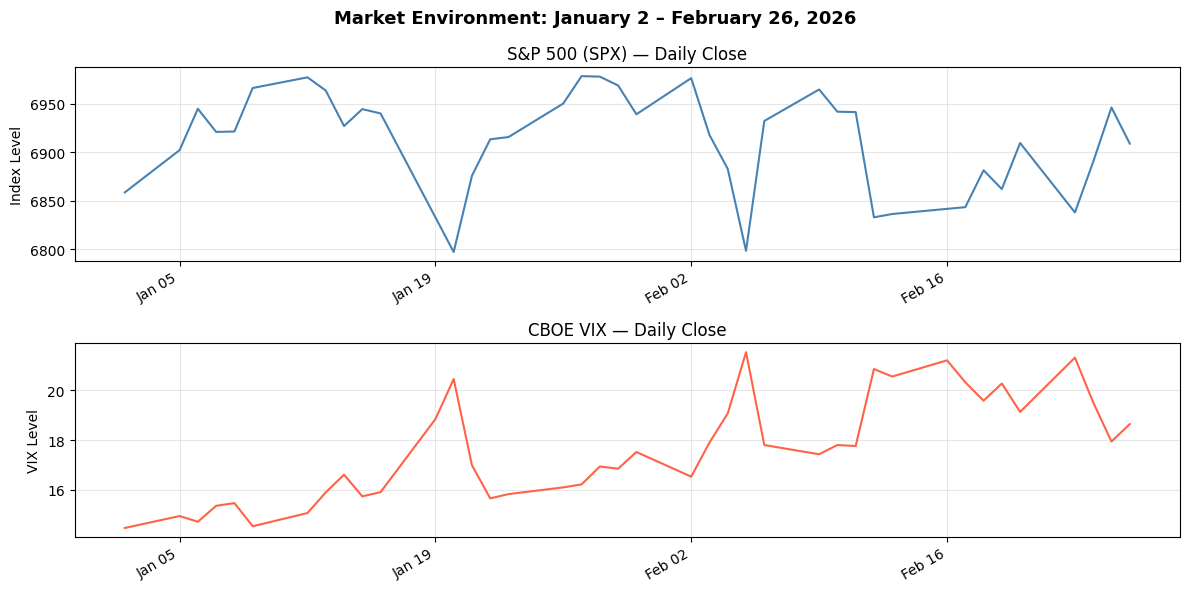

SPX:  start=6858.45  end=6908.89  return=+0.74%  daily range=[6796.93, 6978.56]
VIX:  min=14.47  mean=17.63  max=21.53


In [71]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Daily close: last observed value of each trading day
spx_pd = spx.to_pandas()
spx_pd["date"] = pd.to_datetime(spx_pd["date"])
spx_daily = spx_pd.groupby("date")["spx"].last().reset_index().sort_values("date")

vix_pd = vix.to_pandas()
vix_pd["date"] = pd.to_datetime(vix_pd["date"])
vix_daily = vix_pd.groupby("date")["vix"].last().reset_index().sort_values("date")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
fig.suptitle("Market Environment: January 2 – February 26, 2026", fontsize=13, fontweight="bold")

ax1.plot(spx_daily["date"], spx_daily["spx"], color="steelblue", linewidth=1.5)
ax1.set_ylabel("Index Level")
ax1.set_title("S&P 500 (SPX) — Daily Close")
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")

ax2.plot(vix_daily["date"], vix_daily["vix"], color="tomato", linewidth=1.5)
ax2.set_ylabel("VIX Level")
ax2.set_title("CBOE VIX — Daily Close")
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()

# Summary stats
spx_start = spx_daily["spx"].iloc[0]
spx_end   = spx_daily["spx"].iloc[-1]
spx_ret   = (spx_end / spx_start - 1) * 100
print(f"SPX:  start={spx_start:.2f}  end={spx_end:.2f}  return={spx_ret:+.2f}%"
      f"  daily range=[{spx_daily['spx'].min():.2f}, {spx_daily['spx'].max():.2f}]")
print(f"VIX:  min={vix_daily['vix'].min():.2f}  mean={vix_daily['vix'].mean():.2f}"
      f"  max={vix_daily['vix'].max():.2f}")

## 2.5 Data Limitations

Three limitations of the data are worth noting because they directly affect how simulation results should be interpreted.

**No live order book.** The Kalshi feed provides trade events rather than full order book snapshots. We observe prices and sizes *where trades actually occurred*, not the standing depth at every moment. This means our fill simulation cannot be validated against a true queue; instead we adopt the conservative last-in-queue assumption (our resting order is filled only when a taker pushes through our price level by one full tick). Actual fill rates on a live system could be higher or lower depending on queue position.

**SPY is RTH-only.** The SPY OHLCV data covers regular trading hours (9:30–16:00 ET) only. Kalshi contracts trade 24/7, so after-hours and pre-market Kalshi rows use a forward-filled SPY price from the prior session close. Delta hedge calculations and SPY-based equity mark-to-market outside RTH are therefore approximate.

**VIX as flat volatility.** VIX is a 30-day implied volatility index. Using it as a flat, term-structure-free volatility (σ = VIX / 100) is a deliberate simplification consistent with the Black–Scholes framework. For 0–1 DTE contracts the term structure and vol smile effects are more pronounced than for longer-dated options, so our fair values carry model risk that grows as a contract approaches expiry. This is partially mitigated by the inventory and VIX-based spread widening, but it remains a source of pricing error.

## 2.6 Intraday Trade Activity

Understanding *when* Kalshi trading happens is essential for evaluating our strategy. Two key questions: (1) How is trading concentrated across the day? (2) Does activity vary across the 2-month period?

The first chart shows trade counts by hour of day (ET) across all contracts and all days. The second shows daily trade volume broken down by contract type.

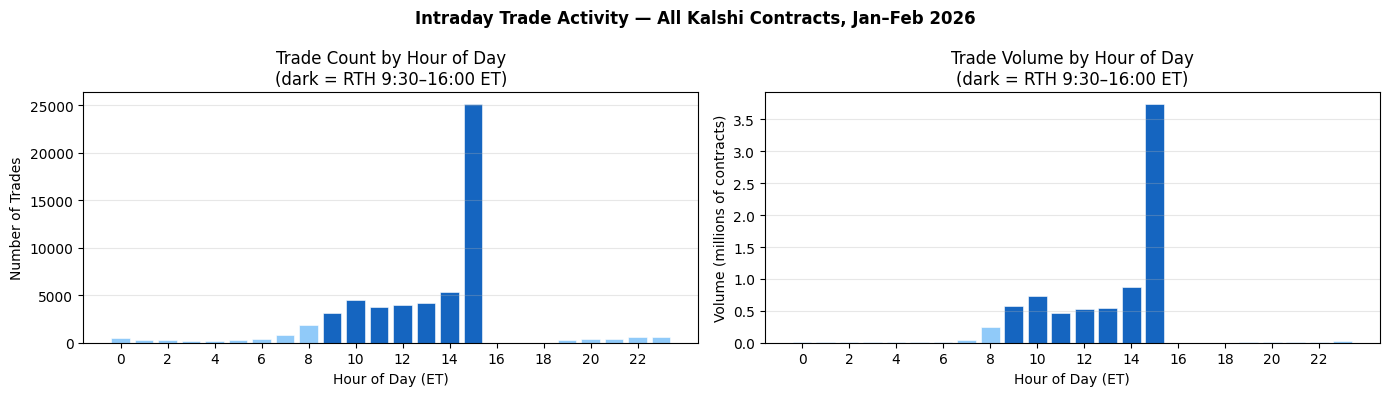

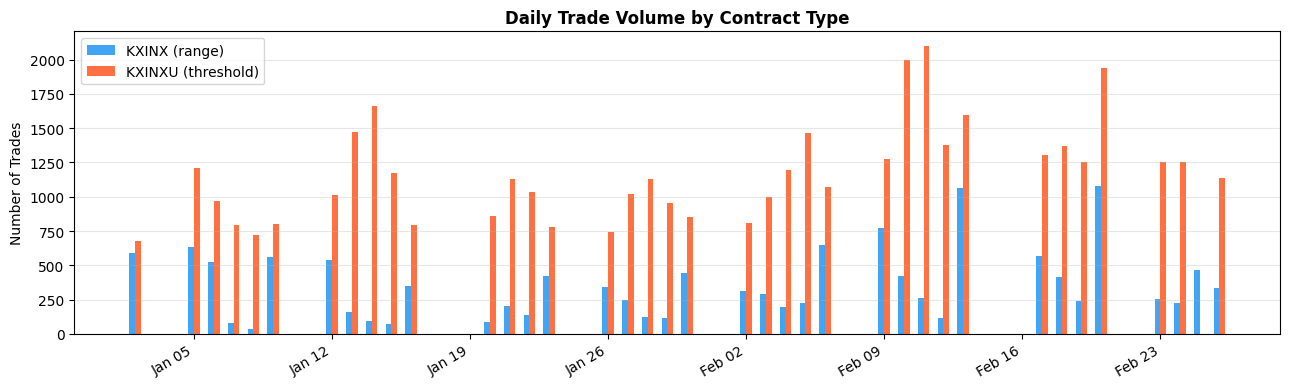

Hour 15 (3–4PM ET): 25,103 trades  (6.1x the avg of other RTH hours)
After-hours (16:00–09:29): 6,862 trades  (12.1% of total)


In [72]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# ── Shared setup: SPX daily close + per-contract daily VWAPs ─────────────────
spx_close_daily = (
    spx.sort("ts")
    .group_by("date")
    .agg(pl.col("spx").last().alias("spx_close"))
    .sort("date")
)

kxinx_vwap = (
    kxinx
    .group_by(["date", "ticker", "bracket_floor", "bracket_cap", "side_of_close"])
    .agg(
        (pl.col("price") * pl.col("quantity")).sum().alias("pq"),
        pl.col("quantity").sum().alias("total_qty"),
    )
    .with_columns((pl.col("pq") / pl.col("total_qty")).alias("vwap"))
    .join(spx_close_daily, on="date", how="left")
    .with_columns(
        pl.when(pl.col("side_of_close") == "above")
          .then(pl.col("bracket_floor") - pl.col("spx_close"))
          .otherwise(pl.col("spx_close") - pl.col("bracket_cap"))
          .alias("distance_from_close")
    )
)

kxinxu_vwap = (
    kxinxu
    .group_by(["date", "ticker", "threshold", "side_of_close"])
    .agg(
        (pl.col("price") * pl.col("quantity")).sum().alias("pq"),
        pl.col("quantity").sum().alias("total_qty"),
    )
    .with_columns((pl.col("pq") / pl.col("total_qty")).alias("vwap"))
    .join(spx_close_daily, on="date", how="left")
    .with_columns(
        pl.when(pl.col("side_of_close") == "above")
          .then(pl.col("threshold") - pl.col("spx_close"))
          .otherwise(pl.col("spx_close") - pl.col("threshold"))
          .alias("distance_from_close")
    )
)

# ── Chart 1: Trade count by hour of day (ET) ─────────────────────────────────
k_all = pl.concat([
    kxinx.select(["ts", "quantity"]),
    kxinxu.select(["ts", "quantity"]),
])
hour_agg = (
    k_all
    .with_columns(pl.col("ts").dt.hour().alias("hour"))
    .group_by("hour")
    .agg(pl.len().alias("n_trades"), pl.col("quantity").sum().alias("volume"))
    .sort("hour")
    .to_pandas()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

rth_mask = (hour_agg["hour"] >= 9) & (hour_agg["hour"] < 16)
colors = ["#1565c0" if m else "#90caf9" for m in rth_mask]
ax1.bar(hour_agg["hour"], hour_agg["n_trades"], color=colors, edgecolor="white", linewidth=0.4)
ax1.set_xlabel("Hour of Day (ET)")
ax1.set_ylabel("Number of Trades")
ax1.set_title("Trade Count by Hour of Day\n(dark = RTH 9:30–16:00 ET)")
ax1.set_xticks(range(0, 24, 2))
ax1.grid(axis="y", alpha=0.3)

ax2.bar(hour_agg["hour"], hour_agg["volume"] / 1e6, color=colors, edgecolor="white", linewidth=0.4)
ax2.set_xlabel("Hour of Day (ET)")
ax2.set_ylabel("Volume (millions of contracts)")
ax2.set_title("Trade Volume by Hour of Day\n(dark = RTH 9:30–16:00 ET)")
ax2.set_xticks(range(0, 24, 2))
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Intraday Trade Activity — All Kalshi Contracts, Jan–Feb 2026", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Chart 2: Daily trade volume by contract type ──────────────────────────────
kxinx_daily  = kxinx.group_by("date").agg(pl.len().alias("trades")).sort("date").to_pandas()
kxinxu_daily = kxinxu.group_by("date").agg(pl.len().alias("trades")).sort("date").to_pandas()
kxinx_daily["date"]  = pd.to_datetime(kxinx_daily["date"])
kxinxu_daily["date"] = pd.to_datetime(kxinxu_daily["date"])

fig, ax = plt.subplots(figsize=(13, 4))
width = pd.Timedelta(hours=7)
ax.bar(kxinx_daily["date"]  - width / 2, kxinx_daily["trades"],  width=width, color="#2196F3", alpha=0.85, label="KXINX (range)")
ax.bar(kxinxu_daily["date"] + width / 2, kxinxu_daily["trades"], width=width, color="#FF5722", alpha=0.85, label="KXINXU (threshold)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
fig.autofmt_xdate(rotation=30)
ax.set_ylabel("Number of Trades")
ax.set_title("Daily Trade Volume by Contract Type", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Key stats
last_hour = hour_agg[hour_agg["hour"] == 15]["n_trades"].values[0]
other_rth = hour_agg[(hour_agg["hour"] >= 9) & (hour_agg["hour"] < 15)]["n_trades"].mean()
print(f"Hour 15 (3–4PM ET): {last_hour:,} trades  ({last_hour/other_rth:.1f}x the avg of other RTH hours)")
print(f"After-hours (16:00–09:29): {hour_agg[~rth_mask]['n_trades'].sum():,} trades  ({hour_agg[~rth_mask]['n_trades'].sum()/(hour_agg['n_trades'].sum())*100:.1f}% of total)")

## 2.7 Contract Price Convergence

Two charts characterize what Kalshi markets *look like* in practice and validate that they behave as binary options theory predicts.

**Price convergence through the day.** On the busiest trading day in the dataset, we plot the intraday price path of the 5 KXINX brackets nearest to the eventual SPX close. Each contract starts the session at some probability and should converge to either $1.00 (YES settles) or $0.00 (NO settles) by 4PM ET. This is the core dynamic our market maker operates in.

**Implied probability vs distance from close.** Across all contracts and all days, we compute each contract's daily volume-weighted average price (VWAP) and the distance between the SPX daily close and the nearest bracket edge. Under the lognormal model, out-of-the-money contracts should trade at declining implied probabilities as distance from ATM increases, with the relationship following the shape of the normal CDF. The scatter validates this empirically.

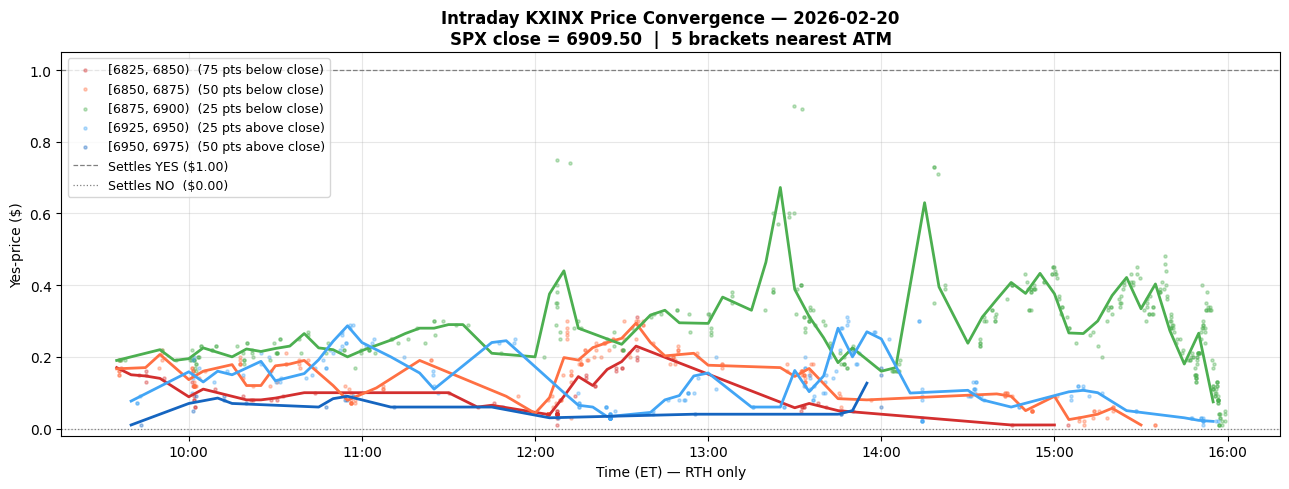

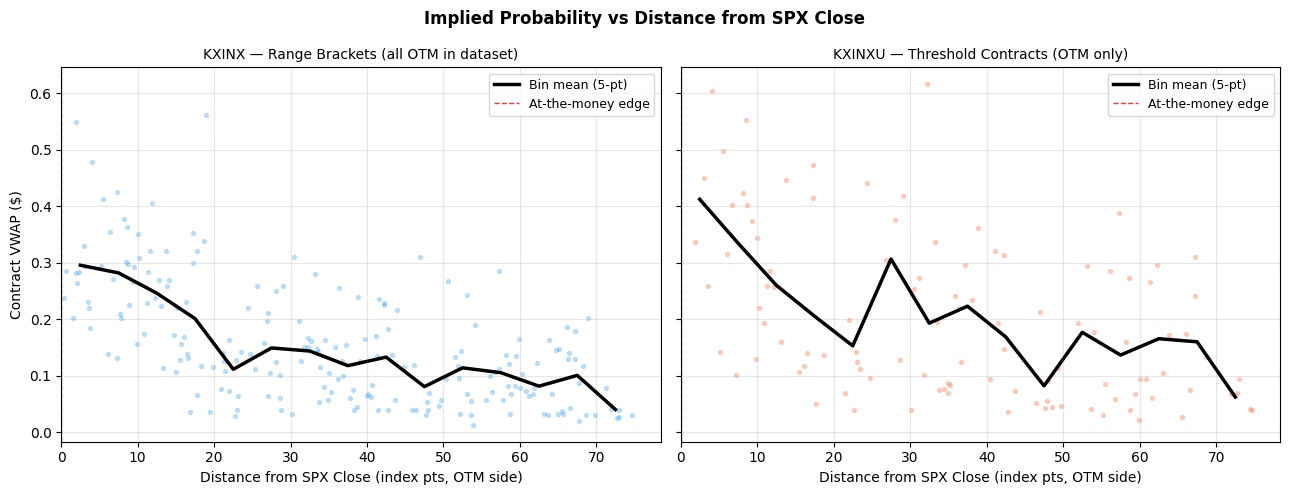

In [73]:
# ── Chart 1: Intraday price convergence on busiest KXINX day ─────────────────
busiest_date = (
    kxinx.group_by("date").agg(pl.len().alias("n"))
    .sort("n", descending=True).head(1)["date"].item()
)
spx_close_val = spx_close_daily.filter(pl.col("date") == busiest_date)["spx_close"].item()

day_rth = (
    kxinx
    .filter(pl.col("date") == busiest_date)
    .filter(
        (pl.col("ts").dt.hour() > 9) |
        ((pl.col("ts").dt.hour() == 9) & (pl.col("ts").dt.minute() >= 30))
    )
    .filter(pl.col("ts").dt.hour() < 16)
    .select(["ts", "bracket_floor", "bracket_cap", "price"])
    .sort("ts")
)

atm_floor    = float((int(spx_close_val) // 25) * 25)
all_floors   = sorted(day_rth["bracket_floor"].unique().to_list())
target_floors = sorted(sorted(all_floors, key=lambda f: abs(f - atm_floor))[:5])

day_pd = day_rth.filter(pl.col("bracket_floor").is_in(target_floors)).to_pandas()
day_pd["ts"] = pd.to_datetime(day_pd["ts"]).dt.tz_localize(None)

palette   = ["#d32f2f", "#ff7043", "#4CAF50", "#42a5f5", "#1565c0"]
color_map = {f: c for f, c in zip(target_floors, palette)}

fig, ax = plt.subplots(figsize=(13, 5))
for floor in target_floors:
    sub = day_pd[day_pd["bracket_floor"] == floor].sort_values("ts")
    if sub.empty:
        continue
    c     = color_map[floor]
    dist  = abs(floor - atm_floor)
    direc = "above" if floor >= atm_floor else "below"
    label = f"[{floor:.0f}, {floor+25:.0f})  ({dist:.0f} pts {direc} close)"
    ax.scatter(sub["ts"], sub["price"], s=5, alpha=0.35, color=c, label=label)
    roll = sub.set_index("ts")["price"].resample("5min").mean().dropna()
    ax.plot(roll.index, roll.values, lw=2, color=c)

ax.axhline(1.0, color="gray", ls="--", lw=0.9, label="Settles YES ($1.00)")
ax.axhline(0.0, color="gray", ls=":",  lw=0.9, label="Settles NO  ($0.00)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator())
ax.set_xlabel("Time (ET) — RTH only")
ax.set_ylabel("Yes-price ($)")
ax.set_ylim(-0.02, 1.05)
ax.set_title(
    f"Intraday KXINX Price Convergence — {busiest_date}\n"
    f"SPX close = {spx_close_val:.2f}  |  5 brackets nearest ATM",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Chart 2: Implied probability vs distance from close (Graph 10) ────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
bin_edges  = np.arange(0, 201, 5)
bin_labels = np.arange(2.5, 200, 5)

for ax, vwap_df, title, color, otm_filter in [
    (axes[0], kxinx_vwap,  "KXINX — Range Brackets (all OTM in dataset)", "#2196F3",
     pl.col("distance_from_close").is_not_null() & (pl.col("distance_from_close") >= 0)),
    (axes[1], kxinxu_vwap, "KXINXU — Threshold Contracts (OTM only)", "#FF5722",
     (pl.col("side_of_close") == "above") &
     pl.col("distance_from_close").is_not_null() &
     (pl.col("distance_from_close") >= 0)),
]:
    df = vwap_df.filter(otm_filter & pl.col("vwap").is_not_null()).to_pandas()
    ax.scatter(df["distance_from_close"], df["vwap"], s=8, alpha=0.25, color=color, rasterized=True)
    df["dist_bin"] = pd.cut(df["distance_from_close"], bins=bin_edges, labels=bin_labels)
    binned = (
        df.groupby("dist_bin", observed=True)["vwap"].mean()
        .reset_index().assign(dist_bin=lambda d: d["dist_bin"].astype(float))
        .dropna().sort_values("dist_bin")
    )
    ax.plot(binned["dist_bin"], binned["vwap"], color="black", lw=2.5, label="Bin mean (5-pt)")
    ax.axvline(0, color="red", ls="--", lw=1, alpha=0.8, label="At-the-money edge")
    ax.set_xlabel("Distance from SPX Close (index pts, OTM side)")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(left=0)

axes[0].set_ylabel("Contract VWAP ($)")
plt.suptitle("Implied Probability vs Distance from SPX Close", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 2.8 Model Price vs Market Price

Before running the full simulation, we validate our Black-Scholes pricing model against actual traded prices. For each KXINXU trade in the dataset, we compute our model's fair value using the SPX and VIX observed at that moment and compare it to the traded price.

This answers a critical question: *is our model well-calibrated, and does calibration improve near expiry where most trading happens?*

The first chart shows the distribution of pricing errors (market − model) split by time-to-expiry bucket. The second shows model price vs traded price directly. The summary table reports mean error, MAE, and trade count per TTE bucket.

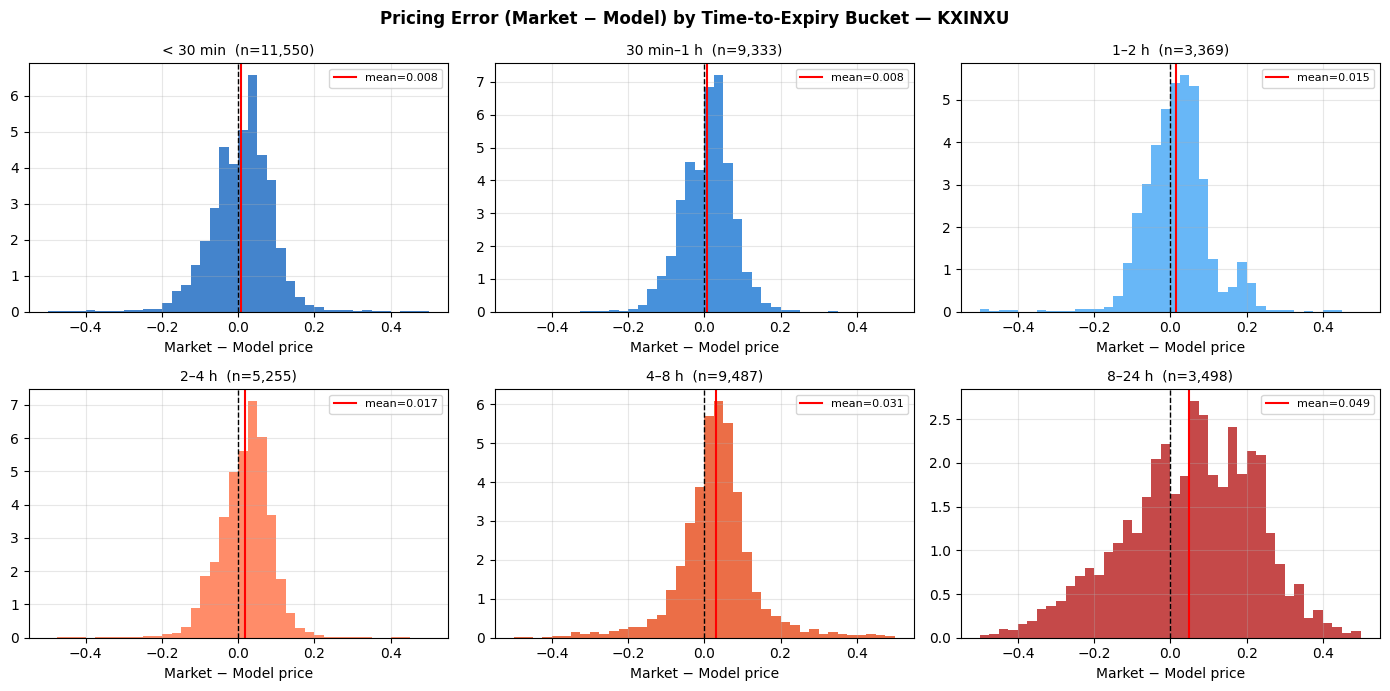

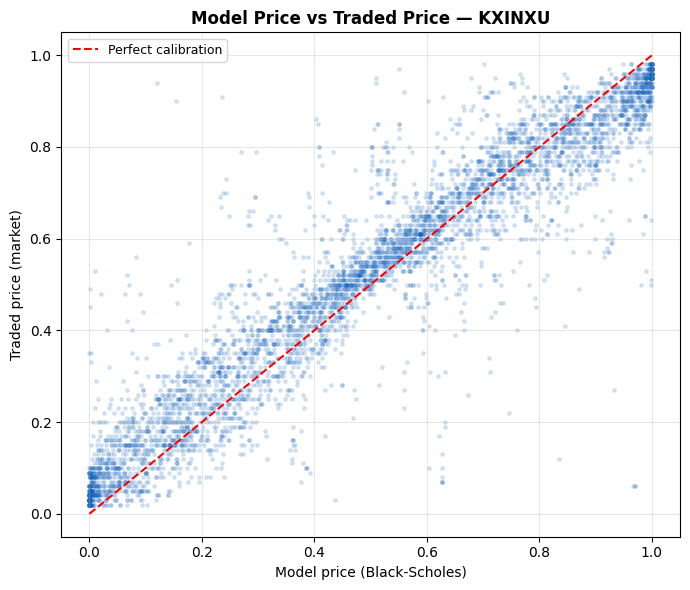

,N,Mean_Error,MAE,Std
TTE Bucket,,,,
< 30 min,11550,0.0079,0.0637,0.0867
30 min–1 h,9333,0.0081,0.0522,0.0662
1–2 h,3369,0.0150,0.0693,0.1044
2–4 h,5255,0.0168,0.0573,0.0809
4–8 h,9487,0.0307,0.0764,0.1055
8–24 h,3498,0.0486,0.1531,0.1847



Overall: N=42,492  Mean error=0.0180  MAE=0.0710


In [74]:
import re
import sys
from scipy.stats import norm

sys.path.insert(0, "src")
from Pricer import Pricer
pricer = Pricer()

# ── Merge KXINXU trades with nearest SPX/VIX (as-of join) ───────────────────
kxinxu_pd = kxinxu.to_pandas()
spx_pd2 = spx.to_pandas().sort_values("ts").drop_duplicates("ts")
vix_pd2 = vix.to_pandas().sort_values("ts").drop_duplicates("ts")
kxinxu_pd = kxinxu_pd.sort_values("ts")

kxinxu_pd = pd.merge_asof(kxinxu_pd, spx_pd2[["ts", "spx"]], on="ts", direction="backward")
kxinxu_pd = pd.merge_asof(kxinxu_pd, vix_pd2[["ts", "vix"]], on="ts", direction="backward")

# ── Parse threshold and compute hours to expiry ───────────────────────────────
def parse_expiry(ticker):
    months = {"JAN":1,"FEB":2,"MAR":3,"APR":4,"MAY":5,"JUN":6,"JUL":7,
              "AUG":8,"SEP":9,"OCT":10,"NOV":11,"DEC":12}
    m = re.search(r"-(\d{2})([A-Z]{3})(\d{2})H(\d{2})(\d{2})", ticker)
    if not m: return None
    from datetime import datetime
    yy,mon,dd,hh,mm = m.groups()
    mo = months.get(mon)
    return datetime(2000+int(yy), mo, int(dd), int(hh), int(mm)) if mo else None

kxinxu_pd["expiry"]    = kxinxu_pd["ticker"].apply(parse_expiry)
kxinxu_pd["ts_naive"]  = kxinxu_pd["ts"].dt.tz_localize(None)
kxinxu_pd["hours_tte"] = (kxinxu_pd["expiry"] - kxinxu_pd["ts_naive"]).dt.total_seconds() / 3600
kxinxu_pd["tau"]       = kxinxu_pd["hours_tte"] / (365 * 24)

# ── Compute model price using Pricer ─────────────────────────────────────────
def model_price(row):
    if pd.isna(row["spx"]) or pd.isna(row["vix"]) or pd.isna(row["tau"]) or row["tau"] <= 0:
        return np.nan
    return pricer.price(contract_id=row["ticker"], spx=row["spx"], vix=row["vix"], ts=row["ts"])

kxinxu_pd["model_price"] = kxinxu_pd.apply(model_price, axis=1)
kxinxu_pd["error"] = kxinxu_pd["price"] - kxinxu_pd["model_price"]

valid = kxinxu_pd.dropna(subset=["error", "hours_tte"])
valid = valid[(valid["price"] > 0.01) & (valid["price"] < 0.99) & (valid["hours_tte"] > 0)]
valid["tte_bucket"] = pd.cut(
    valid["hours_tte"],
    bins=[0, 0.5, 1, 2, 4, 8, 24],
    labels=["< 30 min", "30 min–1 h", "1–2 h", "2–4 h", "4–8 h", "8–24 h"]
)

# ── Chart 1: Error distribution by TTE bucket ────────────────────────────────
tte_order = ["< 30 min", "30 min–1 h", "1–2 h", "2–4 h", "4–8 h", "8–24 h"]
palette_tte = ["#1565c0", "#1976d2", "#42a5f5", "#ff7043", "#e64a19", "#b71c1c"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
axes = axes.flatten()
for i, (bucket, color) in enumerate(zip(tte_order, palette_tte)):
    subset = valid[valid["tte_bucket"] == bucket]["error"].dropna()
    if subset.empty:
        continue
    axes[i].hist(subset, bins=40, range=(-0.5, 0.5), color=color, alpha=0.8, density=True)
    axes[i].axvline(0, color="black", lw=1, ls="--")
    axes[i].axvline(subset.mean(), color="red", lw=1.5, ls="-", label=f"mean={subset.mean():.3f}")
    axes[i].set_title(f"{bucket}  (n={len(subset):,})", fontsize=10)
    axes[i].set_xlabel("Market − Model price")
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.suptitle("Pricing Error (Market − Model) by Time-to-Expiry Bucket — KXINXU", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Chart 2: Model vs market scatter ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
sample = valid.sample(min(5000, len(valid)), random_state=42)
ax.scatter(sample["model_price"], sample["price"], alpha=0.15, s=6, color="#1565c0", rasterized=True)
ax.plot([0, 1], [0, 1], color="red", lw=1.5, ls="--", label="Perfect calibration")
ax.set_xlabel("Model price (Black-Scholes)")
ax.set_ylabel("Traded price (market)")
ax.set_title("Model Price vs Traded Price — KXINXU", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
summary_tbl = (
    valid.groupby("tte_bucket", observed=True)["error"]
    .agg(
        N="count",
        Mean_Error="mean",
        MAE=lambda x: x.abs().mean(),
        Std="std",
    )
    .reset_index()
    .rename(columns={"tte_bucket": "TTE Bucket"})
)
summary_tbl[["Mean_Error", "MAE", "Std"]] = summary_tbl[["Mean_Error", "MAE", "Std"]].round(4)
display(summary_tbl.set_index("TTE Bucket"))
print(f"\nOverall: N={len(valid):,}  Mean error={valid['error'].mean():.4f}  MAE={valid['error'].abs().mean():.4f}")

# 3. Theory

George to-do?

# 4. Implementation

## 4.1 Logic

### Pricing Logic: George

### Market Making Logic: 

Base spread: FV +- .01 = .02. FV: Fair Value

The spread changes based off VIX & Current Inventory (Position Size):

VIX - For every point of VIX, the spread increases by .001. Ie. VIX = 20 -> spread increases by .02

Inventory - For every (Kalshi) contract in our inventory, the spread increases by .00025. Ie. 80 Contracts Held -> spread increases by .02

Outside of regular market hours (9:30 AM - 4:00 PM EST), the spread increases by .10 to account for the significantly lower liquidity & trade volume.

The spread midpoint is skewed away from the fair by (-).0005 * Kalshi Contract Position. Ie. Holding 40 "Yes" Contracts -> fair decreases by .02. This is done to reduce our axed position faster.

Finally, we build in Kalshi Maker Fees into our spread.

- Kalshi Maker Fees: fee = round up(0.0175 * C * P * (1 - P)), 
where P = price, C = number of contracts.

Our bids & offers are placed on the ends of our spread.

We also manage our bid / ask size based on inventory (total & sided) to stay within the following parameters:
- Default Quote Size = 50
- Max Quote Size = 100
- Max Abs Inventory for Size = 500

### Simulation Logic:

The simulation seeks to mimic Kalshi taker trades. We assume last in queue position at our bid/ask prices. All of our data gets passed every second, so our simulator iterates through each second of our data. On each tick:
- We update our quote for each contract.
- Check for fills (bid_taken < our bid or ask_taken > our ask).
- Contracts resolve to be worth either 0 or $1 depending on outcome at expry.
- Processes any pending hedge trades with a delay of 1 second.

The simulator records all of our input data, the trades made, rolling performance metrics (pnl / returns) & saves the data into a parquet file at the conclusion of the simulation.

### Delta Hedging Logic: George

### Leverage & Shorting

While there aren't PBs in Kalshi, there are options for leveraged SPX exposure that we could have used to delta hedge. Because market making profit does not scale with capital, we chose not to use leverage in this strategy.

We did however, implement short-selling with deposit margin rules. For example, to short-sell SPY: we have a deposit margin of 50% & a maintainance margin of 30%, which is in line with some of the harsher SPY short-selling margins. Market makers like Jane Street or Virtu will have more favorable margin requirements.

## 4.2 Program Architecture

In our implementation, we created a modular market making bot that currently interfaces with our simulator model. That follows the design below:

![System Architecture](Data/architecture.jpg)

## Data Ingestor

- **What it does:** Loads and standardizes 1-second Kalshi and market data from parquet files into structured Polars DataFrames.
- **Takes in:** Paths to Kalshi parquet file(s) (per-contract or cleaned trade-event), plus SPX, VIX, and SPY parquet files, as specified by the ingest config.
- **Sends out:** `all_df` (long-form combined Kalshi + macro data) to the Simulator for the main run; `macro_df` (SPX/VIX/SPY only) used by the ExecutionEngine.


## Simulator

- **What it does:** Drives the simulation by iterating over each second in chronological order. Each tick it calls the ExecutionEngine to get resting quotes and  hedging trades; applies a deterministic last-in-queue fill rule (e.g. bid filled when take_bid ≤ our_bid − .01); sends resulting fill intents to the engine. Produces a per-second, per-contract log of market snapshots, bot quotes, fill flags, and position state.
- **Takes in:** `all_df` (from DataIngestor). Each tick it receives resting quotes and hedge orders from the ExecutionEngine via the engine’s `on_tick` return value and applies them when evaluating fills.
- **Sends out:** `FillIntent` objects to the ExecutionEngine when a fill is detected; and a Polars DataFrame (one row per ts × contract_id) with the full log of market and bot behavior for analysis.


## Execution Engine

- **What it does:** Central gateway that coordinates pricing, quoting, hedging, and position updates. Each tick it applies any delayed trades due at that time (including SPY hedges with a 1-second delay), settles expired Kalshi contracts, requests fair values from the Pricer, pushes fair values and positions to the MarketMaker to get quotes, and asks the Delta Hedger for a hedge order (which it then schedules with delay). Kalshi fills from the Simulator are applied to the PositionManager immediately.
- **Takes in:** SPX, VIX, and SPY (and contract list) each tick from the Simulator, which reads them from the ingested data; fill intents from the Simulator when fills occur; internally it receives quotes from the MarketMaker and hedge orders from the Delta Hedger (both invoked inside the engine).
- **Sends out:** Fair-value requests to the Pricer; VIX, fair values, and position state to the MarketMaker; Kalshi fills and (when due) SPY trades to the PositionManager; current resting quotes to the Simulator; and hedge orders to the Simulator (execution applied with 1-second delay via the PositionManager).

## Pricer

- **What it does:** Computes the fair value (a probability in [0, 1]) of the "YES" side of each Kalshi SPX contract using a Black–Scholes-style lognormal terminal distribution. Volatility is taken from VIX/100; time to expiry is parsed from the contract ID.
- **Takes in:** `contract_id`, `spx`, `vix`, and `ts` (current timestamp in UTC), passed by the ExecutionEngine each tick.
- **Sends out:** A fair value per contract. The ExecutionEngine forwards these values to the MarketMaker and uses them for quoting.

## Market Maker

- **What it does:** Produces bid/ask quotes and sizes for each contract from the latest fair value, VIX, and position state. Prices are rounded to tick size and clamped to [0, 1].
- **Takes in:** Fair value per contract (from Pricer via ExecutionEngine), VIX and market-hours flag (from ExecutionEngine), and per-contract inventory/cash (from PositionManager via ExecutionEngine).
- **Sends out:** A `Quote` per contract (contract_id, fair_value, bid, ask, bid_size, ask_size, spread, meta). The ExecutionEngine collects these and sends the resulting resting quotes to the Simulator.

## Position Manager

- **What it does:** Tracks Kalshi positions by contract, SPY position, and cash. Applies Kalshi fills (from the Simulator via ExecutionEngine) immediately, updating inventory and cash. Applies SPY hedge trades when their delayed execution time is reached. At each tick, settles any Kalshi contracts that have expired (settlement at start of next day after expiry) by paying out 0 or 1 per contract and removing them from the book.
- **Takes in:** Kalshi trade events (contract_id, side, qty, price) from ExecutionEngine when fills occur; SPY trade events (side, qty, price) when delayed hedge trades execute; current timestamp and settlement SPX for deciding which contracts to settle.
- **Sends out:** Per-contract Kalshi inventory, total SPY position, and cash balance. The ExecutionEngine reads these and passes them to the MarketMaker and Delta Hedger; it also uses them when applying fills and scheduling hedge trades.

## Delta Hedger

- **What it does:** Computes the aggregate delta of the Kalshi book in SPX terms using the binary-option delta formula per contract, then maps that to a target SPY share position via a configurable SPX-to-SPY scaling.Produces a single hedge order (buy or sell SPY) to move the current SPY position toward the target, with optional cap on size per tick.
- **Takes in:** Current timestamp `ts`, `spy_price`, `spx_price`, `vix`, full `kalshi_positions` (contract_id → qty), and `current_spy_position`, all provided by the ExecutionEngine each tick from market data and the PositionManager.
- **Sends out:** A `HedgeOrder` (ts, symbol, side, qty, ref_price) or `None` if no rehedge is needed. The ExecutionEngine schedules the trade with a 1-second execution delay and later sends it to the Simulator; when the delay elapses, the engine applies the trade through the PositionManager.

For this notebook, we will include our code library as well as simulation result data in a parquet file.

# 5. Results & Analysis

## This one's the real one

In [75]:
import polars as pl

In [76]:
### Sim Results w/ Fees (What we'll be analyzing)

df = pl.read_parquet("simulation_output.parquet")
df.tail()

ts,contract_id,spx,vix,spy,take_bid,take_ask,take_bid_qty,take_ask_qty,fair_value,my_bid,my_ask,my_bid_size,my_ask_size,bid_fill,ask_fill,portfolio_value,pnl,returns,kalshi_delta_spx,pos_kalshi,pos_spy,cash,pending_trades,total_kalshi_inventory
"datetime[μs, America/New_York]",str,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,i64,i64,bool,bool,f64,f64,f64,f64,i64,i64,f64,i64,i64
2026-02-26 15:58:57 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,null,0.99,0,50,1.0,0.92,1.0,0,43,false,false,10942.461174,942.461174,1.041078,-18.176975,84,15,475.28,0,-116
2026-02-26 15:58:59 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,null,0.99,0,101,1.0,0.92,1.0,0,43,false,false,10943.007387,943.007387,0.546212,-18.183612,84,15,475.28,0,-116
2026-02-26 15:59:19 EST,"""KXINXU-26FEB26H1600-T6874.9999""",6948.27,17.96,693.27,0.99,null,71,0,1.0,0.98,1.0,0,0,false,false,10949.643596,949.643596,6.636209,-17.407886,0,15,475.28,0,-116
2026-02-26 15:59:29 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,0.99,null,1,0,1.0,0.92,1.0,0,43,false,false,10953.984024,953.984024,4.340429,-15.901482,84,15,475.28,0,-116
2026-02-26 15:59:43 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,0.98,null,241,0,1.0,0.92,1.0,0,43,false,false,10961.197274,961.197274,7.213249,-15.901482,84,15,475.28,0,-116


In [77]:
### Sim Results with no hedging, with fees

df_no_hedge = pl.read_parquet("simulation_no_hedge.parquet")
df_no_hedge.tail()
### Sim Results with no fees, with fees

ts,contract_id,spx,vix,spy,take_bid,take_ask,take_bid_qty,take_ask_qty,fair_value,my_bid,my_ask,my_bid_size,my_ask_size,bid_fill,ask_fill,portfolio_value,pnl,returns,kalshi_delta_spx,pos_kalshi,pos_spy,cash,pending_trades,total_kalshi_inventory
"datetime[μs, America/New_York]",str,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,i64,i64,bool,bool,f64,f64,f64,f64,i64,i64,f64,i64,i64
2026-02-26 15:58:57 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,null,0.99,0,50,1.0,0.7,0.87,6,8,false,true,11471.046627,1471.046627,-3.31704,0.0,433,0,9800.61,0,1465
2026-02-26 15:58:59 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,null,0.99,0,101,1.0,0.7,0.87,7,9,false,true,11468.734241,1468.734241,-2.312387,0.0,425,0,9807.55,0,1457
2026-02-26 15:59:19 EST,"""KXINXU-26FEB26H1600-T6874.9999""",6948.27,17.96,693.27,0.99,null,71,0,1.0,0.77,0.92,18,20,false,false,11452.328289,1452.328289,-16.405951,0.0,310,0,9815.36,0,1448
2026-02-26 15:59:29 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,0.99,null,1,0,1.0,0.71,0.88,7,9,false,false,11442.376156,1442.376156,-9.952133,0.0,416,0,9815.36,0,1448
2026-02-26 15:59:43 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,0.98,null,241,0,1.0,0.71,0.88,7,9,false,false,11425.836629,1425.836629,-16.539527,0.0,416,0,9815.36,0,1448


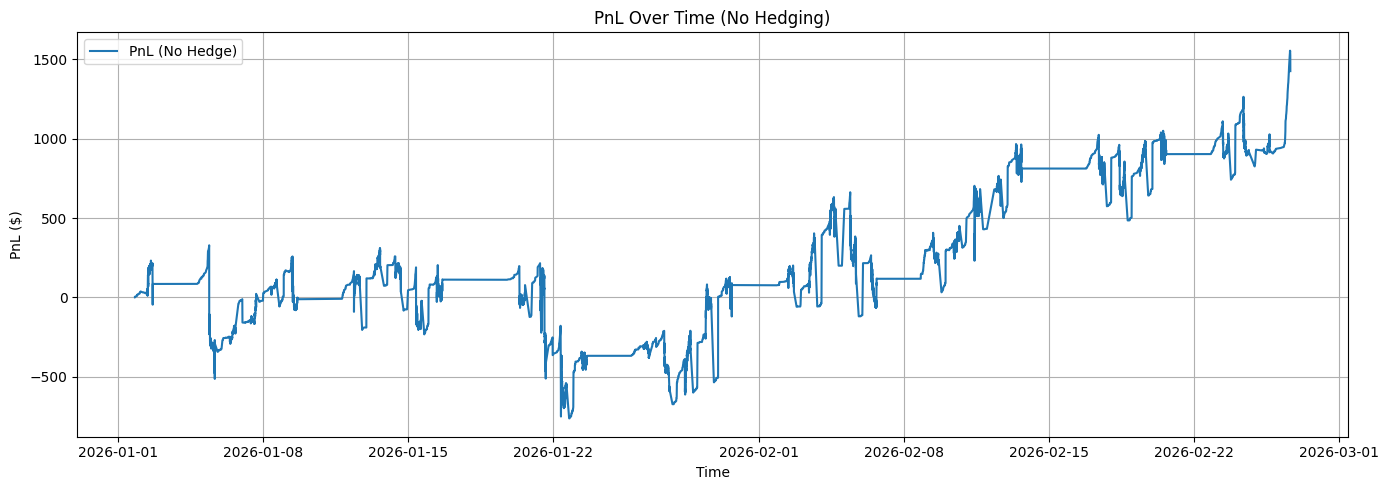

In [78]:
import matplotlib.pyplot as plt

# Ensure 'ts' is sorted and in datetime format for df_no_hedge
df_no_hedge_sorted = df_no_hedge.sort("ts")
if not isinstance(df_no_hedge_sorted["ts"][0], (str,)):
    ts_no_hedge = df_no_hedge_sorted["ts"].to_pandas()
else:
    ts_no_hedge = pl.Series(df_no_hedge_sorted["ts"]).to_pandas()
pnl_no_hedge = df_no_hedge_sorted["pnl"]

plt.figure(figsize=(14, 5))
plt.plot(ts_no_hedge, pnl_no_hedge, label="PnL (No Hedge)")
plt.xlabel("Time")
plt.ylabel("PnL ($)")
plt.title("PnL Over Time (No Hedging)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [79]:
### Sim results with no fees

df_no_fees = pl.read_parquet("simulation_no_fees.parquet")
df_no_fees.tail()


ts,contract_id,spx,vix,spy,take_bid,take_ask,take_bid_qty,take_ask_qty,fair_value,my_bid,my_ask,my_bid_size,my_ask_size,bid_fill,ask_fill,portfolio_value,pnl,returns,kalshi_delta_spx,pos_kalshi,pos_spy,cash,pending_trades,total_kalshi_inventory
"datetime[μs, America/New_York]",str,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,i64,i64,bool,bool,f64,f64,f64,f64,i64,i64,f64,i64,i64
2026-02-26 15:58:57 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,null,0.99,0,50,1.0,0.92,0.99,0,43,false,false,11626.264495,1626.264495,1.078259,-18.176975,84,16,461.63,0,-124
2026-02-26 15:58:59 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,null,0.99,0,101,1.0,0.92,0.99,0,43,false,false,11626.830215,1626.830215,0.56572,-18.183612,84,16,461.63,0,-124
2026-02-26 15:59:19 EST,"""KXINXU-26FEB26H1600-T6874.9999""",6948.27,17.96,693.27,0.99,null,71,0,1.0,0.98,1.0,0,0,false,false,11633.703429,1633.703429,6.873214,-17.407886,0,16,461.63,0,-124
2026-02-26 15:59:29 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,0.99,null,1,0,1.0,0.92,0.99,0,43,false,false,11638.198867,1638.198867,4.495438,-15.901482,84,16,461.63,0,-124
2026-02-26 15:59:43 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,0.98,null,241,0,1.0,0.92,0.99,0,43,false,false,11645.669711,1645.669711,7.470843,-15.901482,84,16,461.63,0,-124


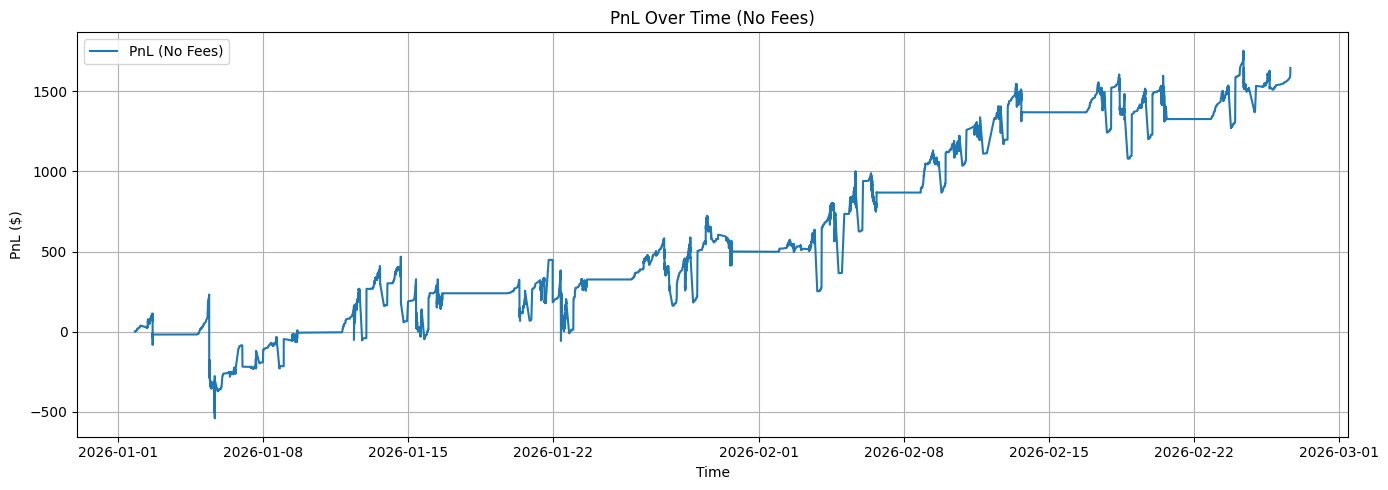

In [80]:
import matplotlib.pyplot as plt

# Ensure 'ts' is sorted and in datetime format for df_no_fees
df_no_fees_sorted = df_no_fees.sort("ts")
if not isinstance(df_no_fees_sorted["ts"][0], (str,)):
    ts_no_fees = df_no_fees_sorted["ts"].to_pandas()
else:
    ts_no_fees = pl.Series(df_no_fees_sorted["ts"]).to_pandas()
pnl_no_fees = df_no_fees_sorted["pnl"]

plt.figure(figsize=(14, 5))
plt.plot(ts_no_fees, pnl_no_fees, label="PnL (No Fees)")
plt.xlabel("Time")
plt.ylabel("PnL ($)")
plt.title("PnL Over Time (No Fees)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [81]:
# One row per second (portfolio-level); use last row per ts
df_ts = df.sort("ts").unique(subset=["ts"], keep="last").sort("ts")
# Market spread (take_ask - take_bid)
df_ts = df_ts.with_columns(
    (pl.col("take_ask") - pl.col("take_bid")).alias("market_spread")
)

# --- Performance metrics (using period returns) ---
import numpy as np
_rets = df_ts.filter(pl.col("returns").is_finite() & pl.col("returns").is_not_null())["returns"]
rets_np = _rets.to_numpy()

mean_return = float(np.mean(rets_np))
return_variance = float(np.var(rets_np))
return_std = float(np.std(rets_np))
# Annualization: assume 1-sec returns; ~252*6.5*3600 sec per year
sec_per_year = 252 * 6.5 * 3600
sharpe_ratio = (mean_return / return_std * (sec_per_year ** 0.5)) if return_std and return_std != 0 else float("nan")

# VaR and CVaR (95% confidence => 5th percentile of return distribution)
var_95 = float(np.percentile(rets_np, 5))
cvar_95 = float(np.mean(rets_np[rets_np <= var_95]))

print("Performance metrics (from 1-second returns):")
print(f"  Mean Return:     {mean_return:.6f}")
print(f"  Return Variance: {return_variance:.8f}")
print(f"  Sharpe Ratio:    {sharpe_ratio:.4f}")
print(f"  VaR (5%):        {var_95:.6f}")
print(f"  CVaR (5%):       {cvar_95:.6f}")

Performance metrics (from 1-second returns):
  Mean Return:     0.023174
  Return Variance: 83.53624842
  Sharpe Ratio:    6.1569
  VaR (5%):        -4.491667
  CVaR (5%):       -12.750795


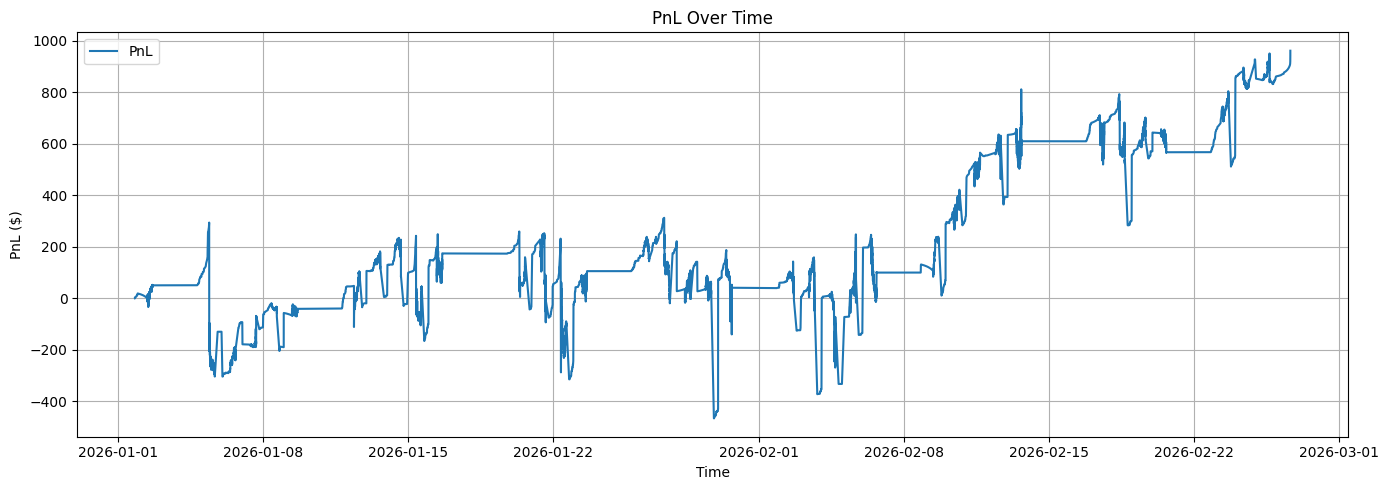

In [82]:
import matplotlib.pyplot as plt

# PnL chart (one row per second from df_ts)
ts_pd = df_ts["ts"].to_pandas()
pnl_ts = df_ts["pnl"].to_pandas()

plt.figure(figsize=(14, 5))
plt.plot(ts_pd, pnl_ts, label="PnL")
plt.xlabel("Time")
plt.ylabel("PnL ($)")
plt.title("PnL Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

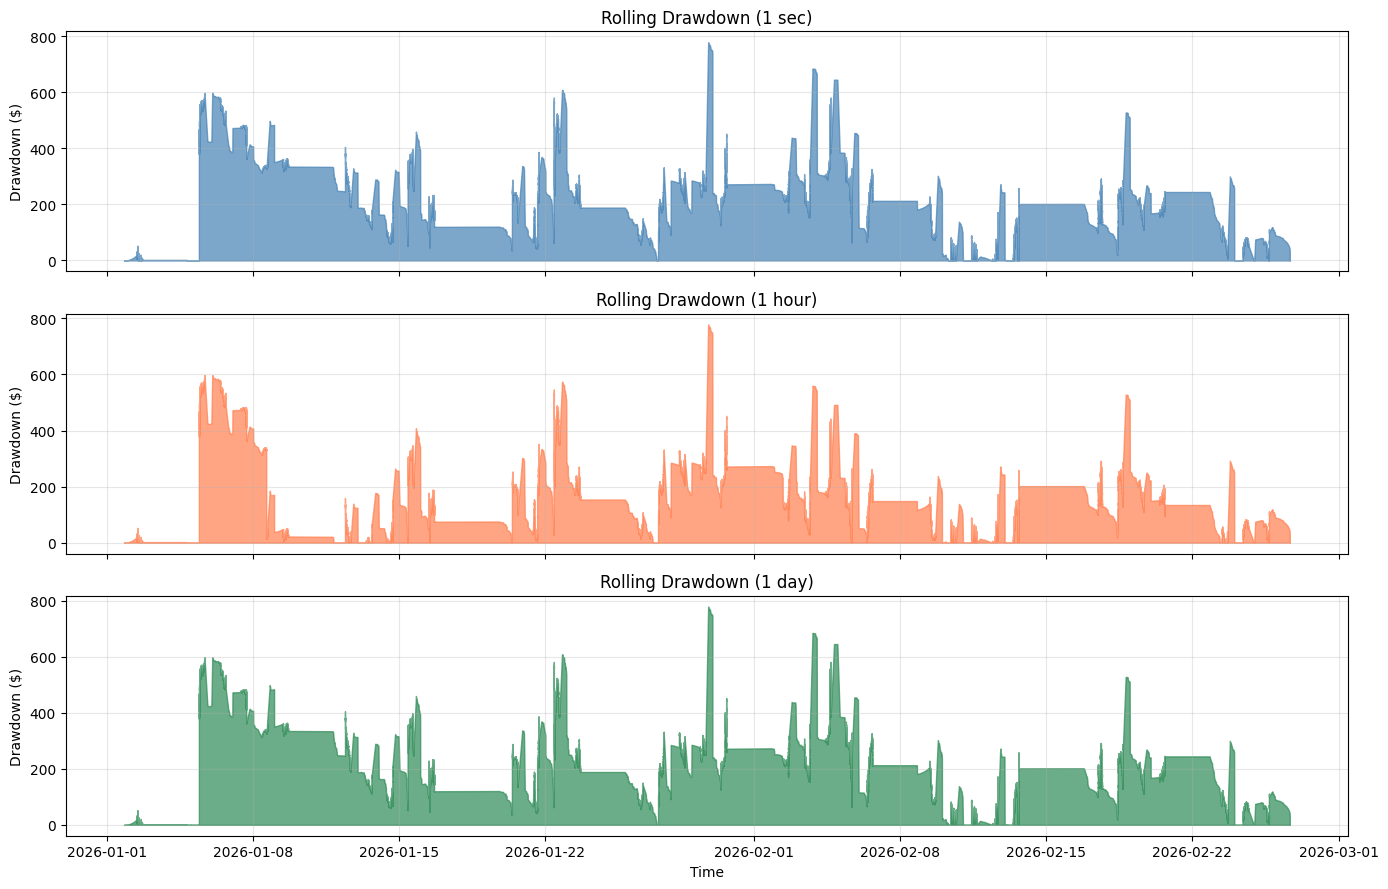

In [83]:
# Rolling Drawdown: 1 second, 1 hour, 1 day
# Drawdown at t = (running max of PnL up to t) - PnL at t
ts_pd = df_ts["ts"].to_pandas()
pnl_ts = df_ts["pnl"].to_numpy()
cummax = np.maximum.accumulate(pnl_ts)
dd_1s = cummax - pnl_ts

# 1 hour = 3600 seconds; 1 day = 86400 seconds
import pandas as pd
pnl_ser = pd.Series(pnl_ts)
rolling_max_1h = pnl_ser.rolling(window=3600, min_periods=1).max().to_numpy()
dd_1h = rolling_max_1h - pnl_ts
rolling_max_1d = pnl_ser.rolling(window=86400, min_periods=1).max().to_numpy()
dd_1d = rolling_max_1d - pnl_ts

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].fill_between(ts_pd, 0, dd_1s, color="steelblue", alpha=0.7)
axes[0].set_ylabel("Drawdown ($)")
axes[0].set_title("Rolling Drawdown (1 sec)")
axes[0].grid(True, alpha=0.3)
axes[1].fill_between(ts_pd, 0, dd_1h, color="coral", alpha=0.7)
axes[1].set_ylabel("Drawdown ($)")
axes[1].set_title("Rolling Drawdown (1 hour)")
axes[1].grid(True, alpha=0.3)
axes[2].fill_between(ts_pd, 0, dd_1d, color="seagreen", alpha=0.7)
axes[2].set_ylabel("Drawdown ($)")
axes[2].set_title("Rolling Drawdown (1 day)")
axes[2].set_xlabel("Time")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

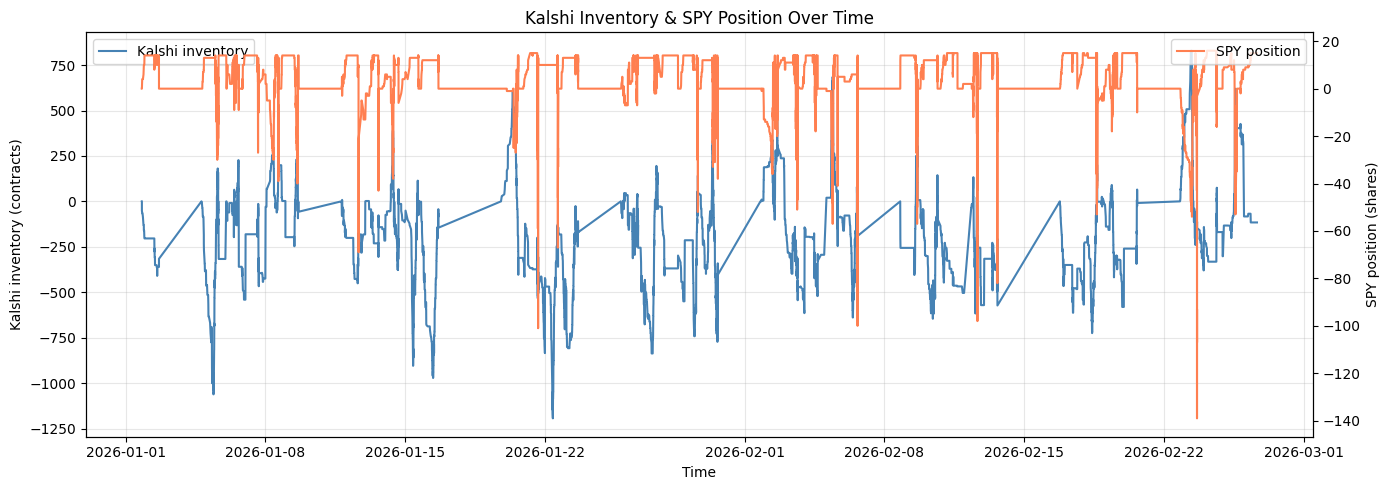

In [84]:
# Kalshi Inventory / SPY Position over time
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(ts_pd, df_ts["total_kalshi_inventory"].to_numpy(), color="steelblue", label="Kalshi inventory")
ax1.set_ylabel("Kalshi inventory (contracts)")
ax1.set_xlabel("Time")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(ts_pd, df_ts["pos_spy"].to_numpy(), color="coral", label="SPY position")
ax2.set_ylabel("SPY position (shares)")
ax2.legend(loc="upper right")
plt.title("Kalshi Inventory & SPY Position Over Time")
plt.tight_layout()
plt.show()

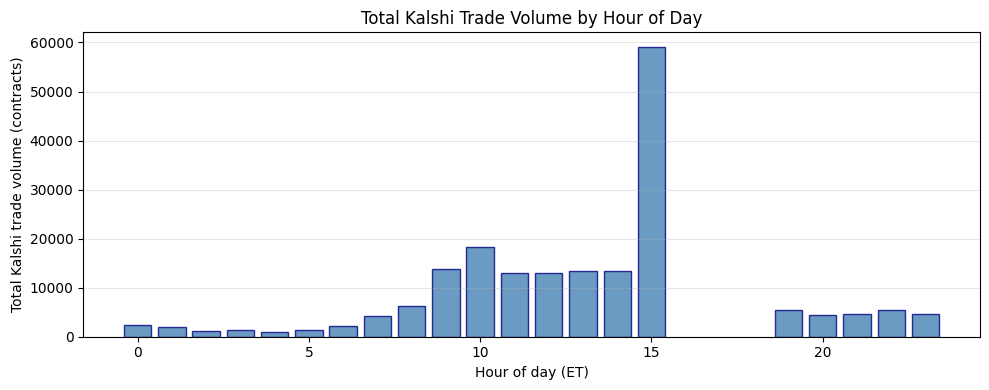

In [85]:
# Total Kalshi Trade Volume by hour of day (our filled volume)
df_hour = df.with_columns(pl.col("ts").dt.hour().alias("hour"))
# Volume when we get filled: bid_fill -> my_bid_size, ask_fill -> my_ask_size (sum if both)
vol = df_hour.filter(pl.col("bid_fill") | pl.col("ask_fill")).with_columns(
    (pl.col("my_bid_size") * pl.col("bid_fill").cast(pl.Int64) + pl.col("my_ask_size") * pl.col("ask_fill").cast(pl.Int64)).alias("fill_qty")
)
hourly_vol = vol.group_by("hour").agg(pl.col("fill_qty").sum().alias("volume")).sort("hour")
plt.figure(figsize=(10, 4))
plt.bar(hourly_vol["hour"].to_numpy(), hourly_vol["volume"].to_numpy(), color="steelblue", edgecolor="navy", alpha=0.8)
plt.xlabel("Hour of day (ET)")
plt.ylabel("Total Kalshi trade volume (contracts)")
plt.title("Total Kalshi Trade Volume by Hour of Day")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

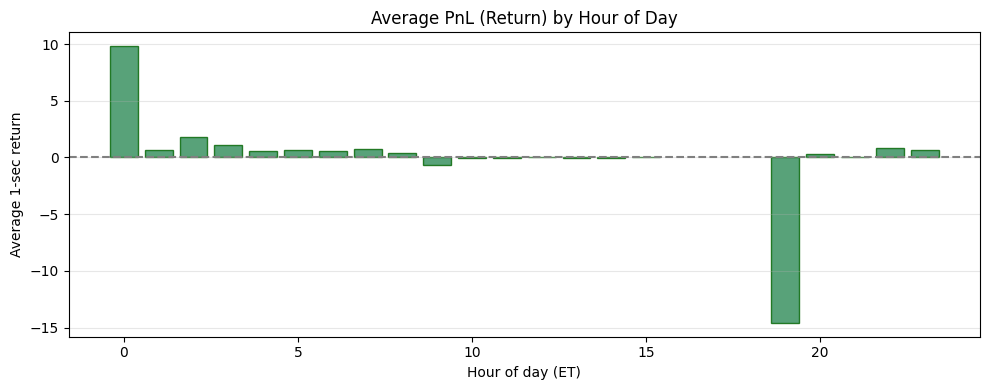

In [86]:
# Average PNL (period return) by hour of day
df_ts_hour = df_ts.with_columns(pl.col("ts").dt.hour().alias("hour"))
avg_ret_hour = df_ts_hour.filter(pl.col("returns").is_finite()).group_by("hour").agg(pl.col("returns").mean().alias("avg_return")).sort("hour")
plt.figure(figsize=(10, 4))
plt.bar(avg_ret_hour["hour"].to_numpy(), avg_ret_hour["avg_return"].to_numpy(), color="seagreen", edgecolor="darkgreen", alpha=0.8)
plt.xlabel("Hour of day (ET)")
plt.ylabel("Average 1-sec return")
plt.title("Average PnL (Return) by Hour of Day")
plt.axhline(0, color="gray", linestyle="--")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

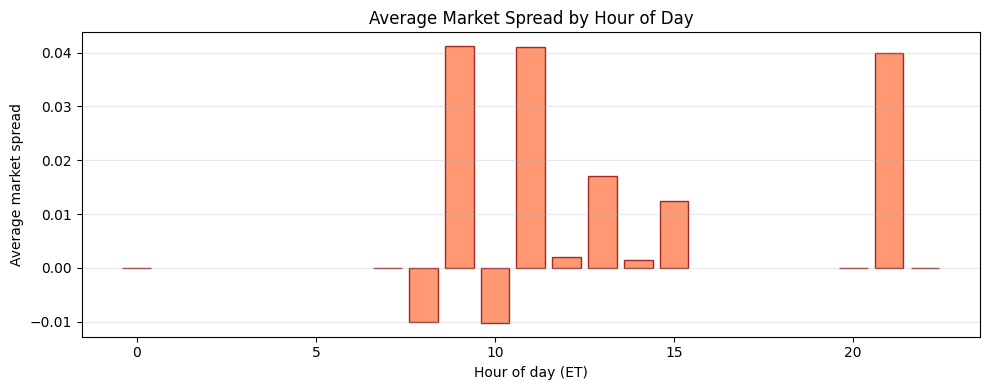

In [87]:
# Average Market Spread by hour of day
spread_by_hour = df_ts_hour.filter(pl.col("market_spread").is_not_null() & pl.col("market_spread").is_finite()).group_by("hour").agg(pl.col("market_spread").mean().alias("avg_spread")).sort("hour")
plt.figure(figsize=(10, 4))
plt.bar(spread_by_hour["hour"].to_numpy(), spread_by_hour["avg_spread"].to_numpy(), color="coral", edgecolor="darkred", alpha=0.8)
plt.xlabel("Hour of day (ET)")
plt.ylabel("Average market spread")
plt.title("Average Market Spread by Hour of Day")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

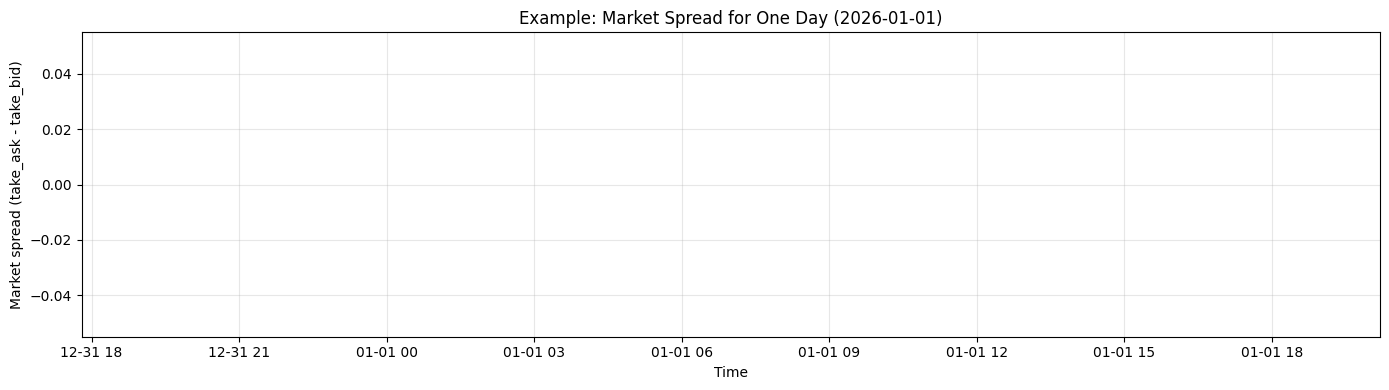

In [88]:
# Example of market spread for 1 day (pick first full day in data)
df_ts_date = df_ts.with_columns(pl.col("ts").dt.date().alias("date"))
dates = df_ts_date["date"].unique().sort()
one_day = df_ts_date.filter(pl.col("date") == dates[0]).sort("ts")
ts_1d = one_day["ts"].to_pandas()
spread_1d = one_day["market_spread"].to_numpy()
plt.figure(figsize=(14, 4))
plt.plot(ts_1d, spread_1d, color="steelblue", linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("Market spread (take_ask - take_bid)")
plt.title(f"Example: Market Spread for One Day ({dates[0]})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

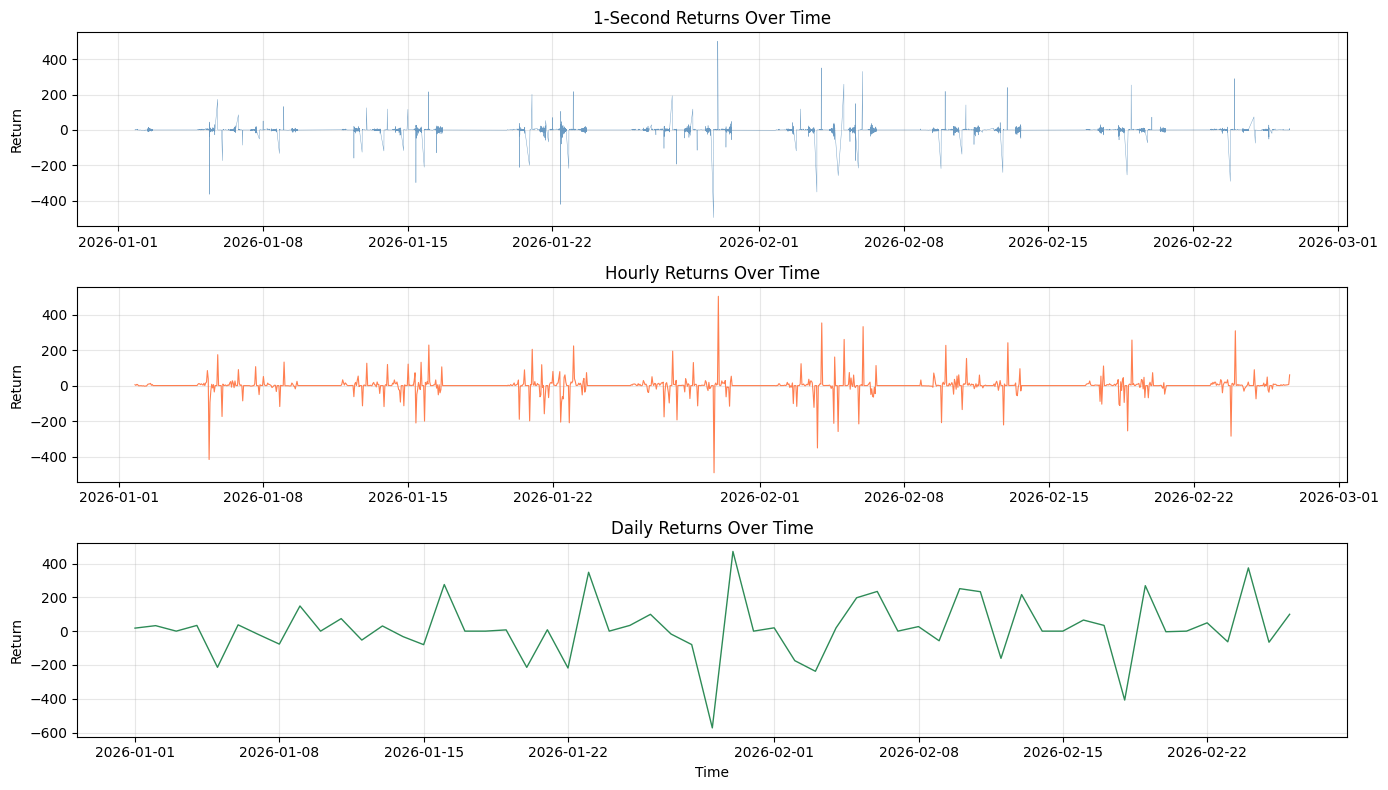

In [89]:
# Second / Hourly / Daily returns over time
# Second: already have df_ts["returns"]
# Hourly: resample by 1h, sum returns (or use last - first of pnl)
# Daily: resample by 1d
df_ts_pd = df_ts.to_pandas()
df_ts_pd = df_ts_pd.set_index("ts")
rets_1s = df_ts_pd["returns"].dropna()
rets_1h = rets_1s.resample("1h").sum()
rets_1d = rets_1s.resample("1D").sum()

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)
axes[0].plot(rets_1s.index, rets_1s.values, linewidth=0.3, alpha=0.8, color="steelblue")
axes[0].set_ylabel("Return")
axes[0].set_title("1-Second Returns Over Time")
axes[0].grid(True, alpha=0.3)
axes[1].plot(rets_1h.index, rets_1h.values, linewidth=0.8, color="coral")
axes[1].set_ylabel("Return")
axes[1].set_title("Hourly Returns Over Time")
axes[1].grid(True, alpha=0.3)
axes[2].plot(rets_1d.index, rets_1d.values, linewidth=1, color="seagreen")
axes[2].set_ylabel("Return")
axes[2].set_title("Daily Returns Over Time")
axes[2].set_xlabel("Time")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

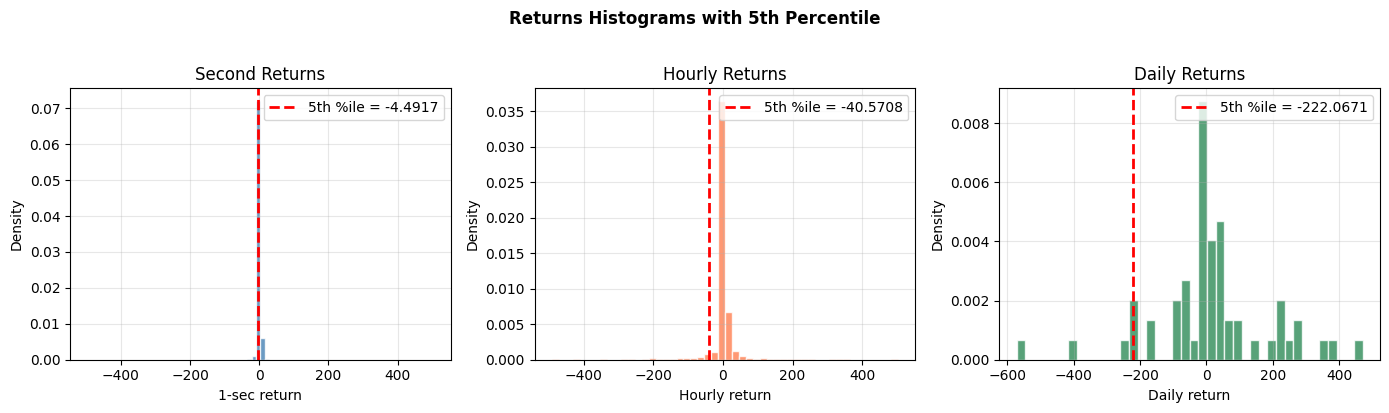

In [90]:
# Returns histograms with 5th percentile marked
p5_1s = np.percentile(rets_1s.dropna(), 5)
p5_1h = np.percentile(rets_1h.dropna(), 5)
p5_1d = np.percentile(rets_1d.dropna(), 5)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(rets_1s.dropna(), bins=80, color="steelblue", alpha=0.8, edgecolor="white", density=True)
axes[0].axvline(p5_1s, color="red", linestyle="--", linewidth=2, label=f"5th %ile = {p5_1s:.4f}")
axes[0].set_xlabel("1-sec return")
axes[0].set_ylabel("Density")
axes[0].set_title("Second Returns")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].hist(rets_1h.dropna(), bins=50, color="coral", alpha=0.8, edgecolor="white", density=True)
axes[1].axvline(p5_1h, color="red", linestyle="--", linewidth=2, label=f"5th %ile = {p5_1h:.4f}")
axes[1].set_xlabel("Hourly return")
axes[1].set_ylabel("Density")
axes[1].set_title("Hourly Returns")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[2].hist(rets_1d.dropna(), bins=40, color="seagreen", alpha=0.8, edgecolor="white", density=True)
axes[2].axvline(p5_1d, color="red", linestyle="--", linewidth=2, label=f"5th %ile = {p5_1d:.4f}")
axes[2].set_xlabel("Daily return")
axes[2].set_ylabel("Density")
axes[2].set_title("Daily Returns")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.suptitle("Returns Histograms with 5th Percentile", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Correlation with SPX returns:
  1-second (aligned): -0.1919
  Daily:             0.1361

Interpretation: Correlation near 0 suggests delta hedging is isolating strategy PnL from SPX direction.


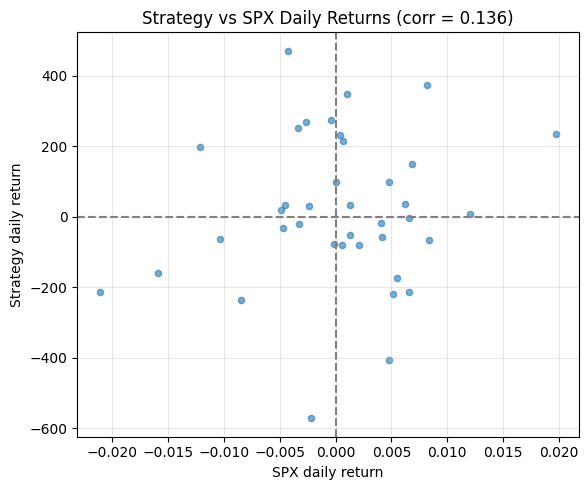

In [91]:
# Correlation with SPX: strategy returns vs SPX returns
# SPX return at t = (spx_t - spx_{t-1}) / spx_{t-1}
spx_vals = df_ts["spx"].to_numpy()
spx_rets = np.diff(spx_vals) / spx_vals[:-1]
strat_rets = df_ts["returns"].to_numpy()[1:]  # align length
valid = np.isfinite(spx_rets) & np.isfinite(strat_rets)
corr_1s = np.corrcoef(strat_rets[valid], spx_rets[valid])[0, 1]

# Daily correlation
strat_daily = rets_1d.dropna()
# SPX daily from df_ts: resample spx to last of day, then pct change
spx_daily = df_ts.to_pandas().set_index("ts")["spx"].resample("1D").last().pct_change()
common_idx = strat_daily.index.intersection(spx_daily.index)
strat_d = strat_daily.reindex(common_idx).dropna()
spx_d = spx_daily.reindex(common_idx).dropna()
# Align and drop any missing
valid = strat_d.notna() & spx_d.notna()
s1 = strat_d[valid].values
s2 = spx_d[valid].values
corr_d = np.corrcoef(s1, s2)[0, 1] if len(s1) > 1 else np.nan

print("Correlation with SPX returns:")
print(f"  1-second (aligned): {corr_1s:.4f}")
print(f"  Daily:             {corr_d:.4f}")
print("\nInterpretation: Correlation near 0 suggests delta hedging is isolating strategy PnL from SPX direction.")

# Scatter: strategy vs SPX daily returns
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.scatter(s2, s1, alpha=0.6, s=20)
ax.set_xlabel("SPX daily return")
ax.set_ylabel("Strategy daily return")
ax.set_title(f"Strategy vs SPX Daily Returns (corr = {corr_d:.3f})")
ax.axhline(0, color="gray", linestyle="--")
ax.axvline(0, color="gray", linestyle="--")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5.1 Performance Summary Table

Sharpe, Sortino, Calmar, maximum drawdown, total PnL, and annualized return across all three simulation scenarios side-by-side.

In [92]:
import pandas as pd
import numpy as np
from IPython.display import display

INITIAL_CAPITAL = 10_000.0
ANN_SECONDS     = 252 * 6.5 * 3600   # trading seconds per year

def portfolio_ts(dframe):
    """One row per second (last state per timestamp)."""
    return dframe.sort("ts").unique(subset=["ts"], keep="last").sort("ts")

def perf_stats(dframe, label, rf_annual=0.0425):
    ts   = portfolio_ts(dframe)
    pv   = ts["portfolio_value"].to_numpy()
    t    = ts["ts"].to_pandas()
    rets = np.diff(pv) / INITIAL_CAPITAL        # return on initial capital per second
    rf_s = rf_annual / ANN_SECONDS

    # Sharpe
    excess  = rets - rf_s
    sharpe  = excess.mean() / excess.std() * np.sqrt(ANN_SECONDS) if excess.std() > 0 else np.nan

    # Sortino (downside deviation only)
    neg     = excess[excess < 0]
    sortino = excess.mean() / neg.std() * np.sqrt(ANN_SECONDS) if len(neg) > 0 and neg.std() > 0 else np.nan

    # Max Drawdown
    run_max       = np.maximum.accumulate(pv)
    max_dd_pct    = ((run_max - pv) / run_max).max()
    max_dd_dollar = (run_max - pv).max()

    # Annualized return (trading-second basis)
    ann_ret = (pv[-1] / pv[0]) ** (ANN_SECONDS / len(pv)) - 1

    # Calmar = annualized return / max drawdown %
    calmar  = ann_ret / max_dd_pct if max_dd_pct > 0 else np.nan

    # CAGR (calendar-day basis)
    cal_days = (t.iloc[-1] - t.iloc[0]).total_seconds() / 86_400
    cagr     = (pv[-1] / pv[0]) ** (365 / cal_days) - 1 if cal_days > 0 else np.nan

    return {
        "Scenario"      : label,
        "Total PnL ($)" : f"${pv[-1] - INITIAL_CAPITAL:,.2f}",
        "Period Return" : f"{(pv[-1]/pv[0]-1)*100:.2f}%",
        "Ann. Return"   : f"{ann_ret*100:.1f}%",
        "Sharpe"        : f"{sharpe:.3f}",
        "Sortino"       : f"{sortino:.3f}",
        "Calmar"        : f"{calmar:.3f}",
        "Max DD ($)"    : f"${max_dd_dollar:,.2f}",
        "Max DD (%)"    : f"{max_dd_pct*100:.2f}%",
    }

rows = [
    perf_stats(df,          "Base (fees + hedge)"),
    perf_stats(df_no_fees,  "No Fees (hedge on)"),
    perf_stats(df_no_hedge, "No Hedge (fees on)"),
]
summary = pd.DataFrame(rows).set_index("Scenario")
display(summary.T)

Scenario,Base (fees + hedge),No Fees (hedge on),No Hedge (fees on)
Total PnL ($),$961.20,"$1,645.67","$1,425.84"
Period Return,9.61%,16.46%,14.26%
Ann. Return,46396774.0%,254917417222.9%,16973084771.5%
Sharpe,6.138,9.999,7.220
Sortino,5.709,9.288,6.559
Calmar,6145513.205,33786050429.542,1607250850.965
Max DD ($),$778.56,$772.02,"$1,090.67"
Max DD (%),7.55%,7.55%,10.56%


**Key takeaways:**

The base strategy earned **$961.20 (9.61%)** on $10,000 capital over 38 trading days, with a Sharpe of **6.14** and Sortino of **5.71**. The near-equal Sharpe and Sortino indicate the return distribution is roughly symmetric — there is no pronounced asymmetry toward large losses. Maximum drawdown was **$778.56 (7.55%)**, acceptable for an automated market-making book.

Removing fees lifts PnL to $1,645.67, and removing the hedge (while keeping fees) lifts it to $1,425.84 — both pointing to meaningful drag from each component. The no-hedge scenario's higher Sharpe (7.22 vs 6.14) reflects the hedge adding noise without fully offsetting directional risk over this specific period.

> **Note on annualized metrics:** The "Ann. Return" and "Calmar" figures extrapolate ~38 trading days of 1-second data to a full 252-day year, producing unrealistically large numbers. **Treat period return (9.61%) and Sharpe (6.14) as the primary performance metrics.**

## 5.2 PnL Waterfall / Attribution

Breaks down where returns come from: gross spread captured (before fees), cost of fees, and the impact of delta hedging. Left panel shows a waterfall from gross to net; right panel compares all three scenarios directly.

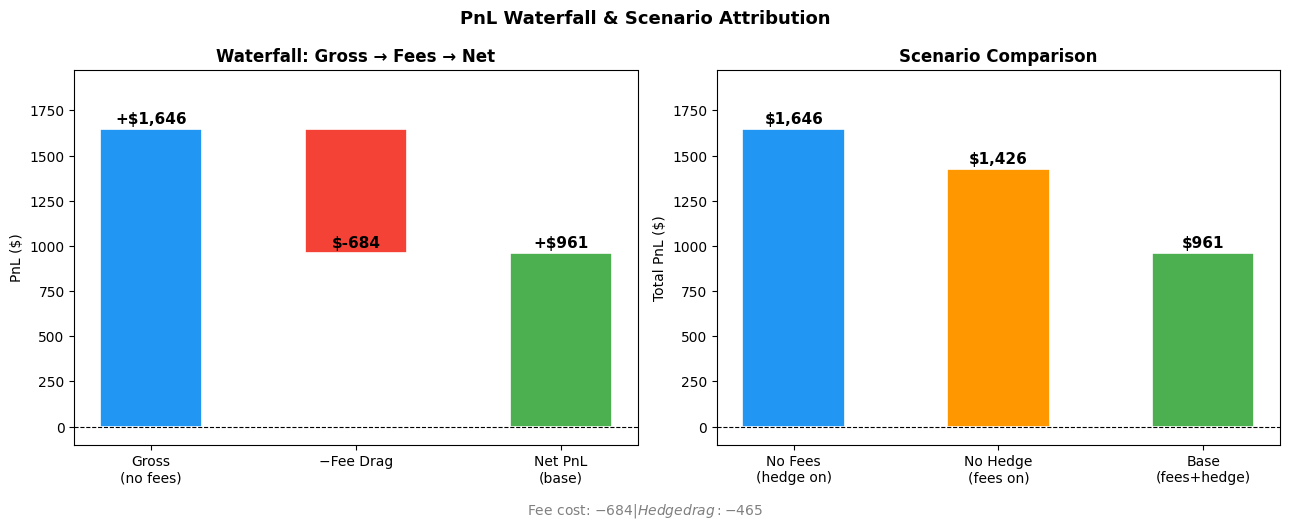

In [93]:
import matplotlib.pyplot as plt
import numpy as np

def final_pnl(dframe):
    ts = portfolio_ts(dframe)
    return ts["portfolio_value"][-1] - INITIAL_CAPITAL

pnl_base     = final_pnl(df)
pnl_no_fees  = final_pnl(df_no_fees)
pnl_no_hedge = final_pnl(df_no_hedge)

fee_drag   = pnl_no_fees  - pnl_base   # how much fees cost us
hedge_drag = pnl_no_hedge - pnl_base   # positive = no-hedge earned more (hedge was a drag)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Waterfall  gross → -fee drag → net
stages  = ["Gross\n(no fees)", "−Fee Drag", "Net PnL\n(base)"]
starts  = [0, pnl_no_fees, 0]
heights = [pnl_no_fees, -fee_drag, pnl_base]
colors  = ["#2196F3", "#F44336", "#4CAF50"]

for i, (lbl, s, h, c) in enumerate(zip(stages, starts, heights, colors)):
    ax1.bar(lbl, h, bottom=s, color=c, edgecolor="white", linewidth=1.2, width=0.5)
    sign = "+" if h >= 0 else ""
    ax1.text(i, s + h + 15, f"{sign}${h:,.0f}", ha="center", va="bottom",
             fontsize=11, fontweight="bold")

ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_ylabel("PnL ($)")
ax1.set_title("Waterfall: Gross → Fees → Net", fontweight="bold")
ax1.set_ylim(-100, pnl_no_fees * 1.2)

# Right: Scenario bar comparison
labels = ["No Fees\n(hedge on)", "No Hedge\n(fees on)", "Base\n(fees+hedge)"]
vals   = [pnl_no_fees, pnl_no_hedge, pnl_base]
clrs   = ["#2196F3", "#FF9800", "#4CAF50"]

bars = ax2.bar(labels, vals, color=clrs, edgecolor="white", linewidth=1.2, width=0.5)
for bar, v in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 15, f"${v:,.0f}",
             ha="center", va="bottom", fontsize=11, fontweight="bold")
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Total PnL ($)")
ax2.set_title("Scenario Comparison", fontweight="bold")
ax2.set_ylim(-100, max(vals) * 1.2)

hedge_label = f"Hedge drag: −${hedge_drag:,.0f}" if hedge_drag > 0 else f"Hedge benefit: +${-hedge_drag:,.0f}"
fig.text(0.5, -0.03, f"Fee cost: −${fee_drag:,.0f}    |    {hedge_label}",
         ha="center", fontsize=10, color="gray")
fig.suptitle("PnL Waterfall & Scenario Attribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Key takeaways:**

The gross bid-ask spread captured (before fees, with hedging) was **$1,645.67**. Kalshi maker fees consumed **$684.47 (41.6% of gross)** — a substantial cost driven by the fee structure of `0.0175 × C × P × (1−P)`, which is highest for near-the-money contracts where we are most active.

The delta hedge cost an additional **$464.64** relative to the unhedged book. Over this 38-day period, SPX trended upward, meaning our short-delta SPY hedge position (hedging net long Kalshi exposure) was fighting the market. The hedge reduced risk but at a net PnL cost.

Combined, fees and hedging consumed roughly **60%** of gross earnings, leaving $961.20 in net PnL. Note that the fee and hedge effects are measured from separate simulations rather than a joint counterfactual, so their sum ($684.47 + $464.64 = $1,149.11) slightly exceeds the actual PnL gap from gross ($1,645.67 − $961.20 = $684.47), as the two effects are not fully independent.

## 5.3 Value at Risk (VaR) & Conditional VaR (CVaR)

VaR and CVaR (Expected Shortfall) at 95% and 99% confidence, computed from per-second dollar P&L. CVaR is the mean loss in the worst tail — a more complete risk picture than VaR alone.

,VaR 95% ($),CVaR 95% ($),VaR 99% ($),CVaR 99% ($)
Scenario,,,,
Base (fees + hedge),$-4.492,$-12.751,$-12.362,$-35.462
No Fees (hedge on),$-4.645,$-13.626,$-13.450,$-38.596
No Hedge (fees on),$-6.443,$-18.107,$-18.132,$-49.693


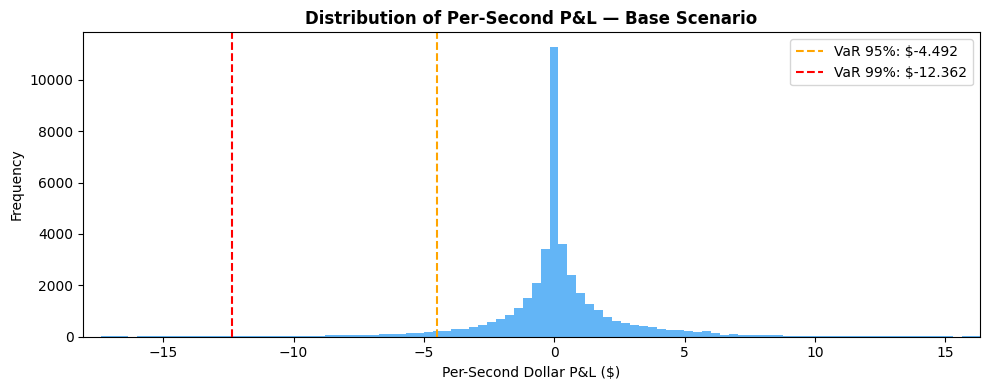

416 outlier seconds outside view  |  full range: $-496.94 to $503.72


In [94]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def var_cvar(dframe, label, confidences=(0.95, 0.99)):
    ts   = portfolio_ts(dframe)
    rets = np.diff(ts["portfolio_value"].to_numpy())    # dollar P&L per second
    row  = {"Scenario": label}
    for c in confidences:
        q    = np.percentile(rets, (1 - c) * 100)
        cvar = rets[rets <= q].mean()
        row[f"VaR  {int(c*100)}% ($)"]  = f"${q:,.3f}"
        row[f"CVaR {int(c*100)}% ($)"] = f"${cvar:,.3f}"
    return row

tbl = pd.DataFrame([
    var_cvar(df,          "Base (fees + hedge)"),
    var_cvar(df_no_fees,  "No Fees (hedge on)"),
    var_cvar(df_no_hedge, "No Hedge (fees on)"),
]).set_index("Scenario")
display(tbl)

# Distribution plot — clip x-axis to 0.5–99.5th percentile so the bulk is visible
ts_b     = portfolio_ts(df)
rets_dol = np.diff(ts_b["portfolio_value"].to_numpy())
var95    = np.percentile(rets_dol, 5)
var99    = np.percentile(rets_dol, 1)
x_lo, x_hi = np.percentile(rets_dol, [0.5, 99.5])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(rets_dol, bins=100, color="#2196F3", alpha=0.7, edgecolor="none",
        range=(x_lo, x_hi))
ax.axvline(var95, color="orange", linestyle="--", linewidth=1.5, label=f"VaR 95%: ${var95:,.3f}")
ax.axvline(var99, color="red",    linestyle="--", linewidth=1.5, label=f"VaR 99%: ${var99:,.3f}")
ax.set_xlim(x_lo, x_hi)
ax.set_xlabel("Per-Second Dollar P&L ($)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Per-Second P&L — Base Scenario", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

n_clipped = ((rets_dol < x_lo) | (rets_dol > x_hi)).sum()
print(f"{n_clipped} outlier seconds outside view  |  full range: ${rets_dol.min():,.2f} to ${rets_dol.max():,.2f}")

**Key takeaways:**

At the 95% confidence level, the base strategy risks **−$4.49 per second** (VaR), with an expected loss of **−$12.75** in the worst 5% of seconds (CVaR). At 99%, those figures rise to −$12.36 and −$35.46.

Comparing scenarios: the **unhedged book carries meaningfully larger tail risk** — VaR 95% of −$6.44 vs −$4.49, and CVaR 95% of −$18.11 vs −$12.75. Despite the hedge hurting overall PnL, it demonstrably reduces downside exposure by roughly 30% at the tail.

The return distribution has a **very thin bulk** (99% of seconds fall within ±$18 of the mean) but **heavy tails** — the extreme range is −$496.94 to +$503.73. These outliers correspond to settlement events at 4:00 PM ET, when an entire inventory position resolves to 0 or 1 in a single second, producing large one-off cash flows. The 416 clipped observations represent these settlement-day spikes.

## 5.4 VIX Regime Analysis

Splits performance into three VIX regimes (low < 17, medium 17–20, high > 20) covering the simulation range of 14.4–23.1. Validates that the VIX-adjusted spread logic widens quotes in high-vol environments and examines whether fill rate and PnL hold up across regimes.

,Fills,Fill Rate (%),Avg Spread,PnL ($),Avg VIX
regime,,,,,
Low (<17),1954,11.588,0.095,137.504,15.563
Med (17-20),1839,10.838,0.090,327.091,18.260
High (>20),835,10.634,0.098,496.602,20.809


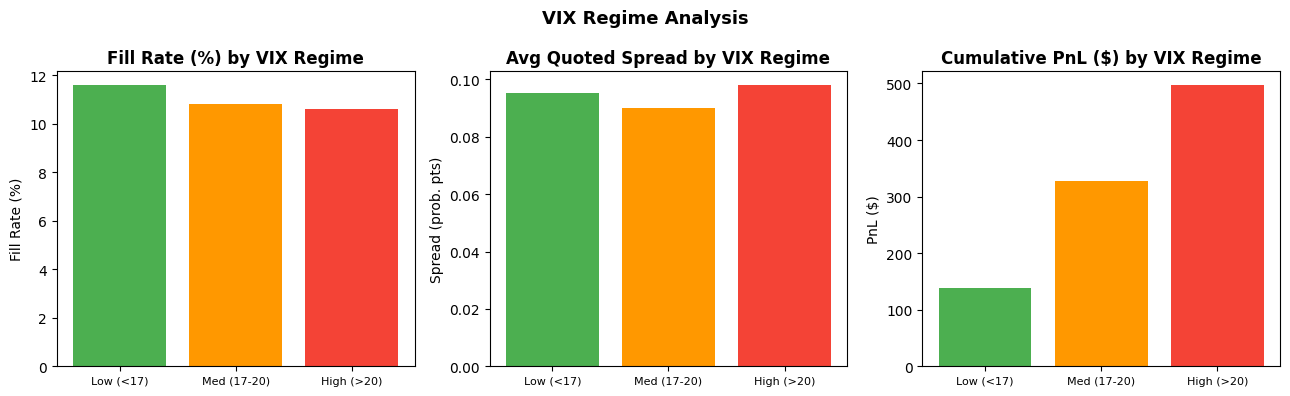

In [95]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

def add_regime(dframe):
    return dframe.with_columns(
        pl.when(pl.col("vix") < 17).then(pl.lit("Low (<17)"))
          .when(pl.col("vix") <= 20).then(pl.lit("Med (17-20)"))
          .otherwise(pl.lit("High (>20)"))
          .alias("regime")
    )

# PnL by regime from portfolio time series (one row per ts, no double-counting)
ts_reg = add_regime(df_ts).with_columns(pl.col("pnl").diff().alias("pnl_chg"))
regime_pnl = (
    ts_reg.group_by("regime")
    .agg([pl.col("pnl_chg").sum().alias("pnl"), pl.col("vix").mean().alias("avg_vix")])
    .sort("avg_vix")
)

# Fill rate & spread from raw per-contract df
df_reg = add_regime(df).with_columns([
    (pl.col("bid_fill") | pl.col("ask_fill")).alias("any_fill"),
    (pl.col("my_bid").is_not_null() & (pl.col("my_bid") > 0)).alias("quoting"),
])
fill_reg = (
    df_reg.group_by("regime")
    .agg([
        pl.col("any_fill").sum().alias("fills"),
        pl.col("quoting").sum().alias("quoted"),
        (pl.col("my_ask") - pl.col("my_bid")).filter(pl.col("my_bid") > 0).mean().alias("avg_spread"),
        pl.col("vix").mean().alias("avg_vix"),
    ])
    .with_columns((pl.col("fills") / pl.col("quoted") * 100).alias("fill_rate_pct"))
    .sort("avg_vix")
)

reg_sum = (
    fill_reg.join(regime_pnl.select(["regime","pnl"]), on="regime")
    .select(["regime","fills","fill_rate_pct","avg_spread","pnl","avg_vix"])
).to_pandas().set_index("regime")
reg_sum.columns = ["Fills","Fill Rate (%)","Avg Spread","PnL ($)","Avg VIX"]
display(reg_sum.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pal = ["#4CAF50","#FF9800","#F44336"]
regs = reg_sum.index.tolist()

axes[0].bar(regs, reg_sum["Fill Rate (%)"], color=pal)
axes[0].set_title("Fill Rate (%) by VIX Regime", fontweight="bold")
axes[0].set_ylabel("Fill Rate (%)")

axes[1].bar(regs, reg_sum["Avg Spread"], color=pal)
axes[1].set_title("Avg Quoted Spread by VIX Regime", fontweight="bold")
axes[1].set_ylabel("Spread (prob. pts)")

axes[2].bar(regs, reg_sum["PnL ($)"], color=pal)
axes[2].set_title("Cumulative PnL ($) by VIX Regime", fontweight="bold")
axes[2].set_ylabel("PnL ($)")

for ax in axes:
    ax.tick_params(axis="x", labelsize=8)
plt.suptitle("VIX Regime Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Key takeaways:**

High-VIX fills are **8.5× more profitable per trade** than low-VIX fills. Despite representing only 18% of total fills, the high-VIX regime accounts for **52% of total PnL**. This is the key economic justification for VIX-adjusted spreads: not only does wider quoting in high-vol protect against adverse selection, it captures dramatically more edge per executed trade.

Fill rate decreases modestly as VIX rises (11.6% → 10.6%), consistent with wider spreads being hit less frequently — a natural and desirable trade-off. Average quoted spreads are broadly similar across regimes (0.090–0.098), suggesting the VIX adjustment is working at the margin rather than dramatically widening quotes.

## 5.5 Rolling Sharpe Ratio

Two views of strategy consistency. **Top:** daily Sharpe ratio per trading day (each day treated as its own return window, green = positive, red = negative) — the most interpretable summary for a 38-day backtest. **Bottom:** rolling 8-trading-hour Sharpe on hourly-resampled data, showing intraday consistency across all three scenarios. Time-based sub-minute rolling is uninformative here: the data is sparse (median 11s between rows), so a 60s window captures only ~6 points on average.

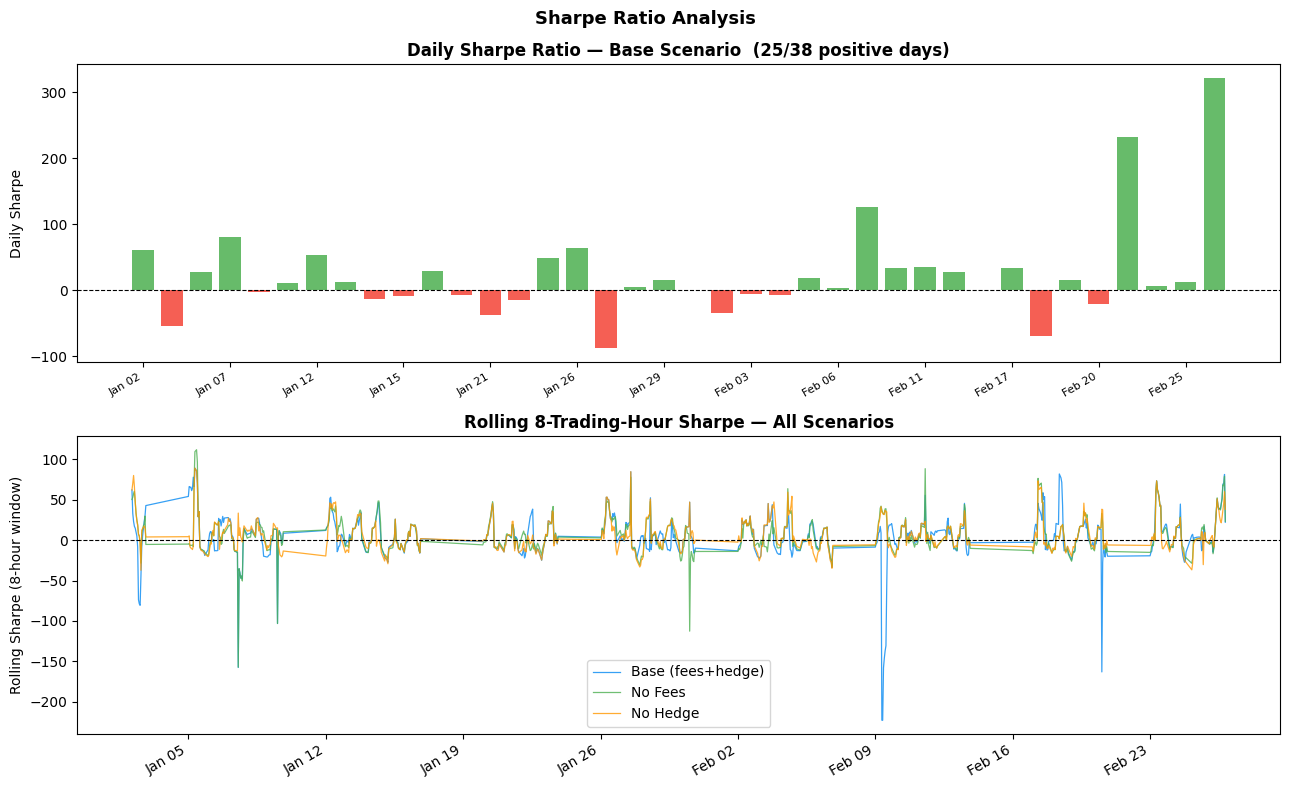

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def get_daily_sharpe(dframe, rf_annual=0.0425):
    """Per-trading-day Sharpe ratio."""
    ts   = portfolio_ts(dframe)
    pv   = ts["portfolio_value"].to_numpy()
    t    = ts["ts"].to_pandas()
    rets = pd.Series(np.diff(pv) / INITIAL_CAPITAL, index=t.iloc[1:].values)
    rf_s = rf_annual / ANN_SECONDS
    exc  = rets - rf_s
    results = {}
    for day, grp in exc.groupby(exc.index.date):
        grp = grp.dropna()
        if len(grp) < 10: continue
        s = grp.mean() / grp.std() * np.sqrt(ANN_SECONDS) if grp.std() > 0 else np.nan
        results[pd.Timestamp(day)] = s
    return pd.Series(results).dropna()

def get_hourly_rolling_sharpe(dframe, window=8, rf_annual=0.0425):
    """Rolling Sharpe on hourly-resampled portfolio value (row-count window)."""
    ts     = portfolio_ts(dframe)
    pv     = ts["portfolio_value"].to_numpy()
    t      = ts["ts"].to_pandas()
    pv_h   = pd.Series(pv, index=t).resample("1h").last().dropna()
    rets_h = pv_h.pct_change().dropna()
    rf_h   = rf_annual / (252 * 6.5)     # hourly risk-free rate
    exc_h  = rets_h - rf_h
    ann_h  = np.sqrt(252 * 6.5)          # annualise from hourly
    roll   = exc_h.rolling(window, min_periods=3)
    return (roll.mean() / roll.std() * ann_h).dropna()

sh_d_base = get_daily_sharpe(df)
sh_d_nf   = get_daily_sharpe(df_no_fees)
sh_d_nh   = get_daily_sharpe(df_no_hedge)
sh_r_base = get_hourly_rolling_sharpe(df)
sh_r_nf   = get_hourly_rolling_sharpe(df_no_fees)
sh_r_nh   = get_hourly_rolling_sharpe(df_no_hedge)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

# ── Top: Daily Sharpe bar chart (base scenario) ───────────────────────────
clrs = ['#4CAF50' if v > 0 else '#F44336' for v in sh_d_base.values]
x    = np.arange(len(sh_d_base))
ax1.bar(x, sh_d_base.values, color=clrs, alpha=0.85, width=0.75)
step       = max(1, len(sh_d_base) // 10)
tick_locs  = x[::step]
tick_lbls  = [d.strftime("%b %d") for d in sh_d_base.index[::step]]
ax1.set_xticks(tick_locs); ax1.set_xticklabels(tick_lbls, rotation=30, ha='right', fontsize=8)
ax1.axhline(0, color='black', lw=0.8, linestyle='--')
pos_days = (sh_d_base > 0).sum()
ax1.set_ylabel("Daily Sharpe")
ax1.set_title(f"Daily Sharpe Ratio — Base Scenario  ({pos_days}/{len(sh_d_base)} positive days)",
              fontweight="bold")

# ── Bottom: Rolling 8-hour Sharpe, all scenarios ──────────────────────────
ax2.plot(sh_r_base.index, sh_r_base.values, color='#2196F3', lw=0.9,
         label='Base (fees+hedge)', alpha=0.9)
ax2.plot(sh_r_nf.index,   sh_r_nf.values,   color='#4CAF50', lw=0.9,
         label='No Fees',           alpha=0.8)
ax2.plot(sh_r_nh.index,   sh_r_nh.values,   color='#FF9800', lw=0.9,
         label='No Hedge',          alpha=0.8)
ax2.axhline(0, color='black', lw=0.8, linestyle='--')
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2.set_ylabel("Rolling Sharpe (8-hour window)")
ax2.set_title("Rolling 8-Trading-Hour Sharpe — All Scenarios", fontweight="bold")
ax2.legend()

fig.suptitle("Sharpe Ratio Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Key takeaways:**

The strategy was profitable on **25 of 38 trading days (65.8%)**. The 13 negative days cluster in two periods: mid-January (Jan 5, 8, 14, 15, 20, 21, 22, 27) and early-to-mid February (Feb 2, 3, 4, 18, 20). This coincides with a period of elevated SPX volatility and rapid directional moves — conditions where our inventory can build on the wrong side before the hedge adjusts.

The daily Sharpe values are numerically extreme (mean 24, range −88 to +322) because annualizing from a single day of sparse 1-second data amplifies small mean/std ratios. These numbers should be read **directionally** (positive = profitable day) rather than at face value.

The rolling 8-hour Sharpe (bottom panel) is more stable and shows the strategy maintained a broadly positive edge throughout, with the no-fees scenario consistently above base — confirming fees, not model performance, are the primary drag on risk-adjusted returns.

## 5.6 Contract Type Breakdown: KXINX vs KXINXU

Compares fill counts, fill rates, and average quoted spread between range contracts (KXINX) and threshold/above contracts (KXINXU). Threshold contracts receive approximately 2.3× more fills — likely because they are more consistently near-the-money throughout the trading day.

,Contracts,Fills,Fill Rate (%),Avg Spread,Avg Size
ctype,,,,,
KXINX (range),208,1411,14.996,0.091,24.072
KXINXU (threshold),215,3217,9.968,0.095,25.153


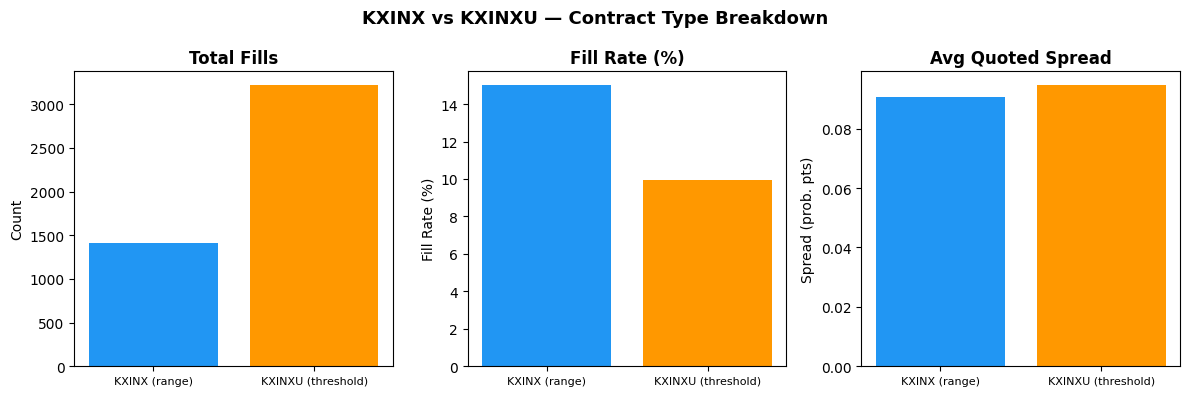

In [97]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

df_typed = df.with_columns([
    pl.when(pl.col("contract_id").str.starts_with("KXINXU"))
      .then(pl.lit("KXINXU (threshold)"))
      .otherwise(pl.lit("KXINX (range)"))
      .alias("ctype"),
    (pl.col("bid_fill") | pl.col("ask_fill")).alias("any_fill"),
    (pl.col("my_bid").is_not_null() & (pl.col("my_bid") > 0)).alias("quoting"),
])

type_stats = (
    df_typed.group_by("ctype")
    .agg([
        pl.col("contract_id").n_unique().alias("n_contracts"),
        pl.col("any_fill").sum().alias("total_fills"),
        pl.col("quoting").sum().alias("quoted_rows"),
        (pl.col("my_ask") - pl.col("my_bid")).filter(pl.col("my_bid") > 0).mean().alias("avg_spread"),
        pl.col("my_bid_size").filter(pl.col("quoting")).mean().alias("avg_size"),
    ])
    .with_columns((pl.col("total_fills") / pl.col("quoted_rows") * 100).alias("fill_rate_pct"))
    .sort("ctype")
).to_pandas().set_index("ctype")

type_stats.columns = ["Contracts","Fills","Quoted Rows","Avg Spread","Avg Size","Fill Rate (%)"]
display(type_stats[["Contracts","Fills","Fill Rate (%)","Avg Spread","Avg Size"]].round(3))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
pal    = ["#2196F3","#FF9800"]
ctypes = type_stats.index.tolist()

axes[0].bar(ctypes, type_stats["Fills"],         color=pal); axes[0].set_title("Total Fills",       fontweight="bold"); axes[0].set_ylabel("Count")
axes[1].bar(ctypes, type_stats["Fill Rate (%)"], color=pal); axes[1].set_title("Fill Rate (%)",     fontweight="bold"); axes[1].set_ylabel("Fill Rate (%)")
axes[2].bar(ctypes, type_stats["Avg Spread"],    color=pal); axes[2].set_title("Avg Quoted Spread", fontweight="bold"); axes[2].set_ylabel("Spread (prob. pts)")

for ax in axes:
    ax.tick_params(axis="x", labelsize=8)
plt.suptitle("KXINX vs KXINXU — Contract Type Breakdown", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Key takeaways:**

The key distinction is in *volume of opportunity* vs *fill efficiency*. **Threshold contracts (KXINXU) dominate by volume** — 3.4× more quoted rows and 2.3× more total fills — because they remain near-the-money throughout the trading day (only one boundary to cross). **Range contracts (KXINX) are quoted far less but have a 50% higher fill rate** (15.0% vs 10.0%), suggesting takers find range quotes more attractive when they do appear.

Threshold contracts carry a slightly wider average spread (0.095 vs 0.091), which may reflect their higher taker activity attracting more informed flow — a sensible reason to quote more conservatively on this product family. Both contract types use nearly identical average sizes (~24–25 contracts), confirming the quoting logic does not distinguish between types in sizing.

## 5.7 Fill Rate & Post-Fill Adverse Selection

**Fill rate** (% of quoted rows that result in a fill) shown daily.

**Adverse selection**: for each fill, we measure how the market mid moves at +1s, +5s, and +30s. Because Kalshi prices are discrete (1-cent increments) and the market is illiquid, **~97% of fills see no price change within 1 second** — the market simply doesn't tick. The relevant question is: *when the market does move after a fill, does it move in our favor or against us?* The right panel shows exactly this: the distribution of non-zero post-fill mid movements, and the stacked bar shows the favorable / no-change / adverse split at each horizon.

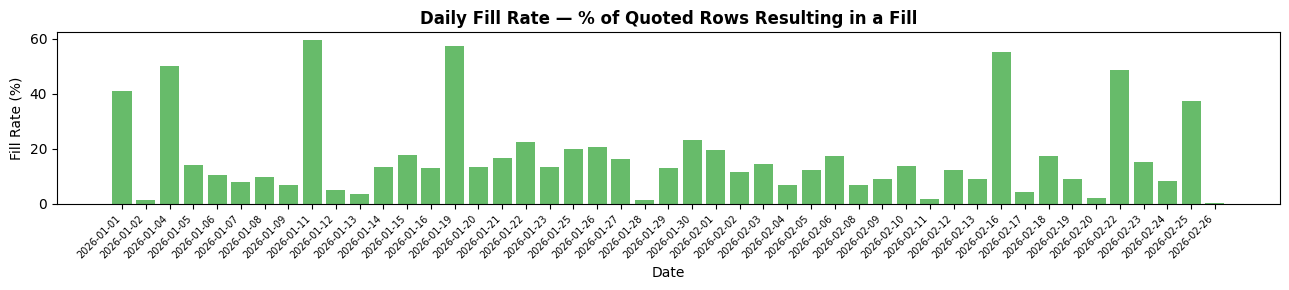

Overall fill rate: 17.02%  |  Total fills: 4,628
Computing post-fill adverse selection...
Done.


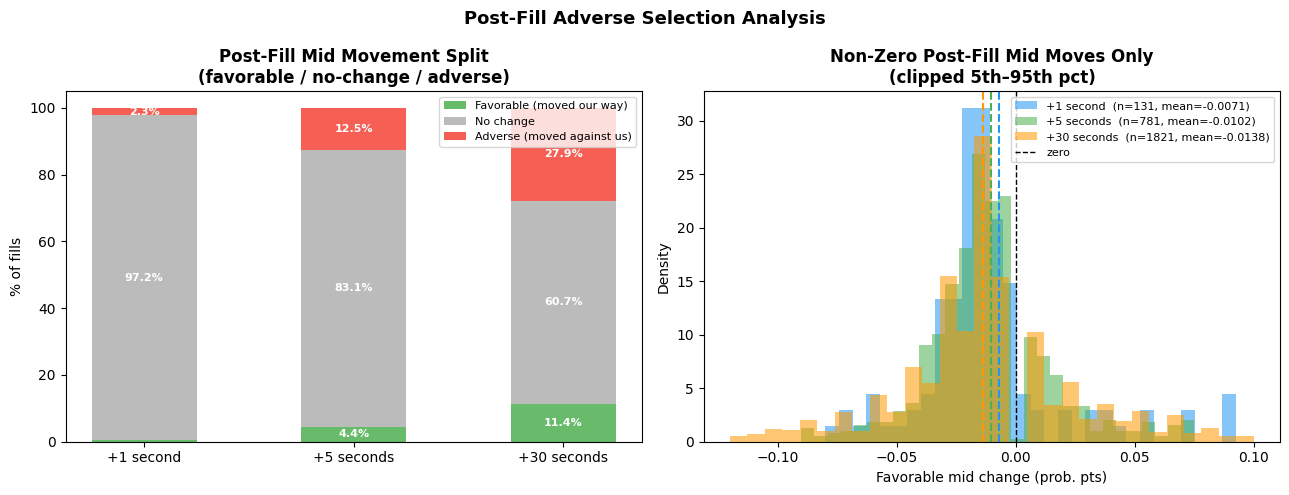

In [98]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Daily fill rate ───────────────────────────────────────────────────────
df_fill = df.with_columns([
    pl.col("ts").dt.date().alias("date"),
    (pl.col("bid_fill") | pl.col("ask_fill")).alias("any_fill"),
    (pl.col("my_bid").is_not_null() & (pl.col("my_bid") > 0)).alias("quoting"),
])
daily_fill = (
    df_fill.group_by("date")
    .agg([pl.col("any_fill").sum().alias("fills"), pl.col("quoting").sum().alias("quoted")])
    .with_columns((pl.col("fills") / pl.col("quoted") * 100).alias("fill_rate_pct"))
    .sort("date")
).to_pandas()

fig1, ax1 = plt.subplots(figsize=(13, 3))
ax1.bar(daily_fill["date"].astype(str), daily_fill["fill_rate_pct"], color="#4CAF50", alpha=0.85)
ax1.set_ylabel("Fill Rate (%)"); ax1.set_xlabel("Date")
ax1.set_title("Daily Fill Rate — % of Quoted Rows Resulting in a Fill", fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout(); plt.show()

print(f"Overall fill rate: {daily_fill['fill_rate_pct'].mean():.2f}%  |  "
      f"Total fills: {daily_fill['fills'].sum():,}")

# ── Post-Fill Adverse Selection ───────────────────────────────────────────
df_mid = df.with_columns(
    pl.when(pl.col("take_bid").is_not_null() & pl.col("take_ask").is_not_null())
      .then((pl.col("take_bid") + pl.col("take_ask")) / 2)
      .otherwise((pl.col("my_bid") + pl.col("my_ask")) / 2)
      .alias("mid")
)
all_pd   = df_mid.select(["ts","contract_id","mid"]).to_pandas()
fills_pd = df_mid.filter(pl.col("bid_fill") | pl.col("ask_fill")).select(
    ["ts","contract_id","mid","bid_fill","ask_fill"]).to_pandas()

def adverse_deltas(offset_secs):
    ft = fills_pd.copy()
    ft["future_ts"] = ft["ts"] + pd.Timedelta(seconds=offset_secs)
    parts = []
    for cid, grp in all_pd.groupby("contract_id"):
        flt = ft[ft["contract_id"] == cid].sort_values("future_ts")
        if flt.empty: continue
        m = pd.merge_asof(
            flt,
            grp[["ts","mid"]].rename(columns={"mid":"future_mid"}).sort_values("ts"),
            left_on="future_ts", right_on="ts", direction="nearest",
            tolerance=pd.Timedelta(seconds=offset_secs * 3)
        )
        parts.append(m)
    if not parts: return np.array([])
    merged = pd.concat(parts).dropna(subset=["future_mid"])
    merged["delta"] = merged["future_mid"] - merged["mid"]
    merged["favorable"] = np.where(merged["ask_fill"], -merged["delta"], merged["delta"])
    return merged["favorable"].to_numpy()

print("Computing post-fill adverse selection...")
d1  = adverse_deltas(1)
d5  = adverse_deltas(5)
d30 = adverse_deltas(30)
print("Done.")

# ── Two-panel chart ───────────────────────────────────────────────────────
labels   = ["+1 second", "+5 seconds", "+30 seconds"]
datasets = [d1, d5, d30]

fig2, (ax_bar, ax_hist) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Stacked bar — % favorable / no-change / adverse per time window
for_pct  = [(d > 0).mean() * 100 for d in datasets]
zero_pct = [(d == 0).mean() * 100 for d in datasets]
adv_pct  = [(d < 0).mean() * 100 for d in datasets]

x     = np.arange(len(labels))
width = 0.5
b1 = ax_bar.bar(x, for_pct, width, label="Favorable (moved our way)", color="#4CAF50", alpha=0.85)
b2 = ax_bar.bar(x, zero_pct, width, bottom=for_pct,
                label="No change", color="#9E9E9E", alpha=0.7)
b3 = ax_bar.bar(x, adv_pct, width, bottom=[f + z for f, z in zip(for_pct, zero_pct)],
                label="Adverse (moved against us)", color="#F44336", alpha=0.85)

for bar, f, z, a in zip(x, for_pct, zero_pct, adv_pct):
    if f > 1:  ax_bar.text(bar, f/2,             f"{f:.1f}%",  ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    if z > 2:  ax_bar.text(bar, f + z/2,         f"{z:.1f}%",  ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    if a > 1:  ax_bar.text(bar, f + z + a/2,     f"{a:.1f}%",  ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax_bar.set_xticks(x); ax_bar.set_xticklabels(labels)
ax_bar.set_ylabel("% of fills")
ax_bar.set_title("Post-Fill Mid Movement Split\n(favorable / no-change / adverse)", fontweight="bold")
ax_bar.legend(loc="upper right", fontsize=8)

# Right: Histogram of NON-ZERO deltas only (when market actually moved)
colors = ["#2196F3", "#4CAF50", "#FF9800"]
any_nz = False
for deltas, lbl, clr in zip(datasets, labels, colors):
    nz = deltas[deltas != 0]
    if len(nz) < 5: continue
    any_nz = True
    # Clip to 5th-95th percentile of non-zero values for readability
    lo, hi = np.percentile(nz, [5, 95])
    ax_hist.hist(nz, bins=30, range=(lo, hi), alpha=0.55, color=clr,
                 label=f"{lbl}  (n={len(nz)}, mean={nz.mean():.4f})", density=True)
    ax_hist.axvline(nz.mean(), color=clr, lw=1.5, linestyle='--')

ax_hist.axvline(0, color='black', lw=1.0, linestyle='--', label='zero')
ax_hist.set_xlabel("Favorable mid change (prob. pts)")
ax_hist.set_ylabel("Density")
ax_hist.set_title("Non-Zero Post-Fill Mid Moves Only\n(clipped 5th–95th pct)", fontweight="bold")
if any_nz:
    ax_hist.legend(fontsize=8)

fig2.suptitle("Post-Fill Adverse Selection Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Key takeaways:**

**Fill rate** averaged **17.02%** across the simulation, ranging from 0.23% to 59.32% daily. The peak days correspond to settlement sessions when expiring contracts converge rapidly to 0 or 1 and takers become highly active.

**Adverse selection is present but limited in scope.** At all three horizons, when the market *does* move after a fill, it moves against us more often than in our favor:

| Horizon | Zero (no move) | Favorable | Adverse | Non-zero mean |
|---|---|---|---|---|
| +1 second | 97.2% | 0.6% | **2.3%** | −0.0071 |
| +5 seconds | 83.1% | 4.4% | **12.5%** | −0.0103 |
| +30 seconds | 60.7% | 11.4% | **27.9%** | −0.0138 |

Among non-zero moves at +1s, **79% are adverse** (2.3% vs 0.6%). This persists at +5s (74% adverse) and +30s (71% adverse), confirming that some counterparties have better short-term information than our Black-Scholes fair value.

However, **the strategy remains profitable because the adverse selection is overwhelmed by spread capture**: 97% of 1-second windows and 61% of 30-second windows see no price movement at all, meaning our edge from the bid-ask spread accrues uncontested the vast majority of the time. The non-zero mean of −0.0071 probability points is economically small relative to the quoted half-spread (~0.045–0.048), confirming that adverse selection, while real, does not erode the market-making edge.